# Projet de Machine Learning 

In [77]:
# Chargement des librairies nécessaires
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)

#librairies pour CARTµ
library(rpart)
library(rpart.plot)
library(partykit)

In [78]:
# Pour installer les packages si besoin

#install.packages("ggplot2")
#install.packages("tidyverse")
#install.packages("gridExtra")
#install.packages("GGally")

#install.packages("corrpolt")

#install.packages("FactoMineR")
#install.packages("factoextra")


#install.packages("MASS")
#install.packages("dplyr")

#install.packages("stats")
#install.packages("graphics")
#install.packages("pROC")







#packages <- c("ggplot2","tidyverse","gridExtra","GGally","plotly","corrplot","reshape2","FactoMineR","factoextra","glmnet","ggfortify","pROC","ROCR")

# 1. Introduction


## Présentation du jeu de données 


Dans ce projet, nous nous intéressons à un jeu de données synthétique comprenant 15 000 dossiers de patients, intégrant des variables démographiques, physiologiques et comportementales (âge, IMC, pression artérielle, cholestérol, habitudes de vie, etc.). Bien que ces données soient artificielles, elles ont été construites de manière à reproduire des corrélations réalistes observées en pratique médicale.

L’objectif principal est de prédire le risque de maladie cardiovasculaire (Heart_Disease_Risk) à partir de l’ensemble des variables explicatives, en mobilisant différentes méthodes de machine learning. Dans un second temps, nous chercherons également à prédire le taux de cholestérol LDL, indicateur clé du risque cardiovasculaire.

Pour répondre à ces objectifs, nous commencerons par une analyse exploratoire approfondie des données afin de mieux comprendre leur structure et les relations entre variables. Nous comparerons ensuite plusieurs modèles de prédiction, en évaluant leurs performances et leur capacité d’interprétation. Enfin, nous discuterons la cohérence des résultats obtenus au regard de l’analyse descriptive initiale.

Les données sont extraites et mises en forme, elles sont décrites par les variables suivantes :
* **Patient_ID** : identifiant unique pour chaque patient ;  
* **Age** : âge du patient (en années) ;  
* **Gender** : genre du patient ; qualitative à deux modalités ;  
* **Height_cm** : taille du patient en centimètres ;  
* **Weight_kg** : poids du patient en kilogrammes ;  
* **BMI** : indice de masse corporelle (IMC), calculé à partir de la taille et du poids (kg/m²) ;  
* **Systolic_BP** : pression artérielle systolique (mmHg) ;  
* **Diastolic_BP** : pression artérielle diastolique (mmHg) ;  
* **Cholesterol_Total** : cholestérol sérique total (mg/dL) ;  
* **Cholesterol_LDL** : lipoprotéines de basse densité (« mauvais » cholestérol) (mg/dL) ;  
* **Cholesterol_HDL** : lipoprotéines de haute densité (« bon » cholestérol) (mg/dL) ;  
* **Fasting_Blood_Sugar** : taux de glycémie à jeun (mg/dL) ;  
* **Smoking_Status** : statut tabagique ; qualitative à deux modalités ;  
* **Alcohol_Consumption** : niveau de consommation d’alcool ; qualitative à trois modalités ;  
* **Physical_Activity_Level** : niveau d’activité physique ; qualitative à quatre modalités ;  
* **Family_History** : antécédents familiaux de maladie cardiaque ; qualitative à deux modalités ;  
* **Stress_Level** : niveau de stress auto-déclaré ; échelle de 1 à 10 ;  
* **Sleep_Hours** : nombre moyen d’heures de sommeil par nuit ;  
* **Heart_Disease_Risk** : risque d’accident cardiaque ; qualitative à deux modalités : 0 (risque faible) ou 1 (risque élevé).  

In [79]:
# Lecture des données
# path="http://www.math.univ-toulouse.fr/~besse/Wikistat/data/"
path <- "./"
data <- read.table(paste(path, "healthcare_synthetic_data.csv", sep = ""),
                    sep = ",", header = TRUE)
# Affiche les premières lignes du jeu de données 
head(data)
# Vérification du contenu
summary(data)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

In [80]:
# données "propres", sans trous, bien codées et de petites tailles ?

In [81]:
# Conversion des variables qualitatives en facteur 

data[, "Gender"] <- as.factor(data[, "Gender"])
data[, "Smoking_Status"] <- as.factor(data[, "Smoking_Status"])
data[, "Alcohol_Consumption"] <- as.factor(data[, "Alcohol_Consumption"])
data[, "Physical_Activity_Level"] <- as.factor(data[, "Physical_Activity_Level"])
data[, "Family_History"] <- as.factor(data[, "Family_History"])
data[, "Heart_Disease_Risk"] <- as.factor(data[, "Heart_Disease_Risk"])

# est ce que on compte stress level en quali ou quanti ? Stress_Level : niveau de stress auto-déclaré : échelle de 1 à 10 ; 

# 2. Analyse exploratoire des données

Étapes descriptives préliminaires uni- et multidimensionnelle visant à repérer les incohérences, les variables non significatives ou de distribution exotique, les individus non concernés ou atypiques... et à étudier les structures des données. Ce peut être aussi la longue étape de construction de variables, attributs ou features spécifiques des données.

### Analyse descriptive unidimensionnelles

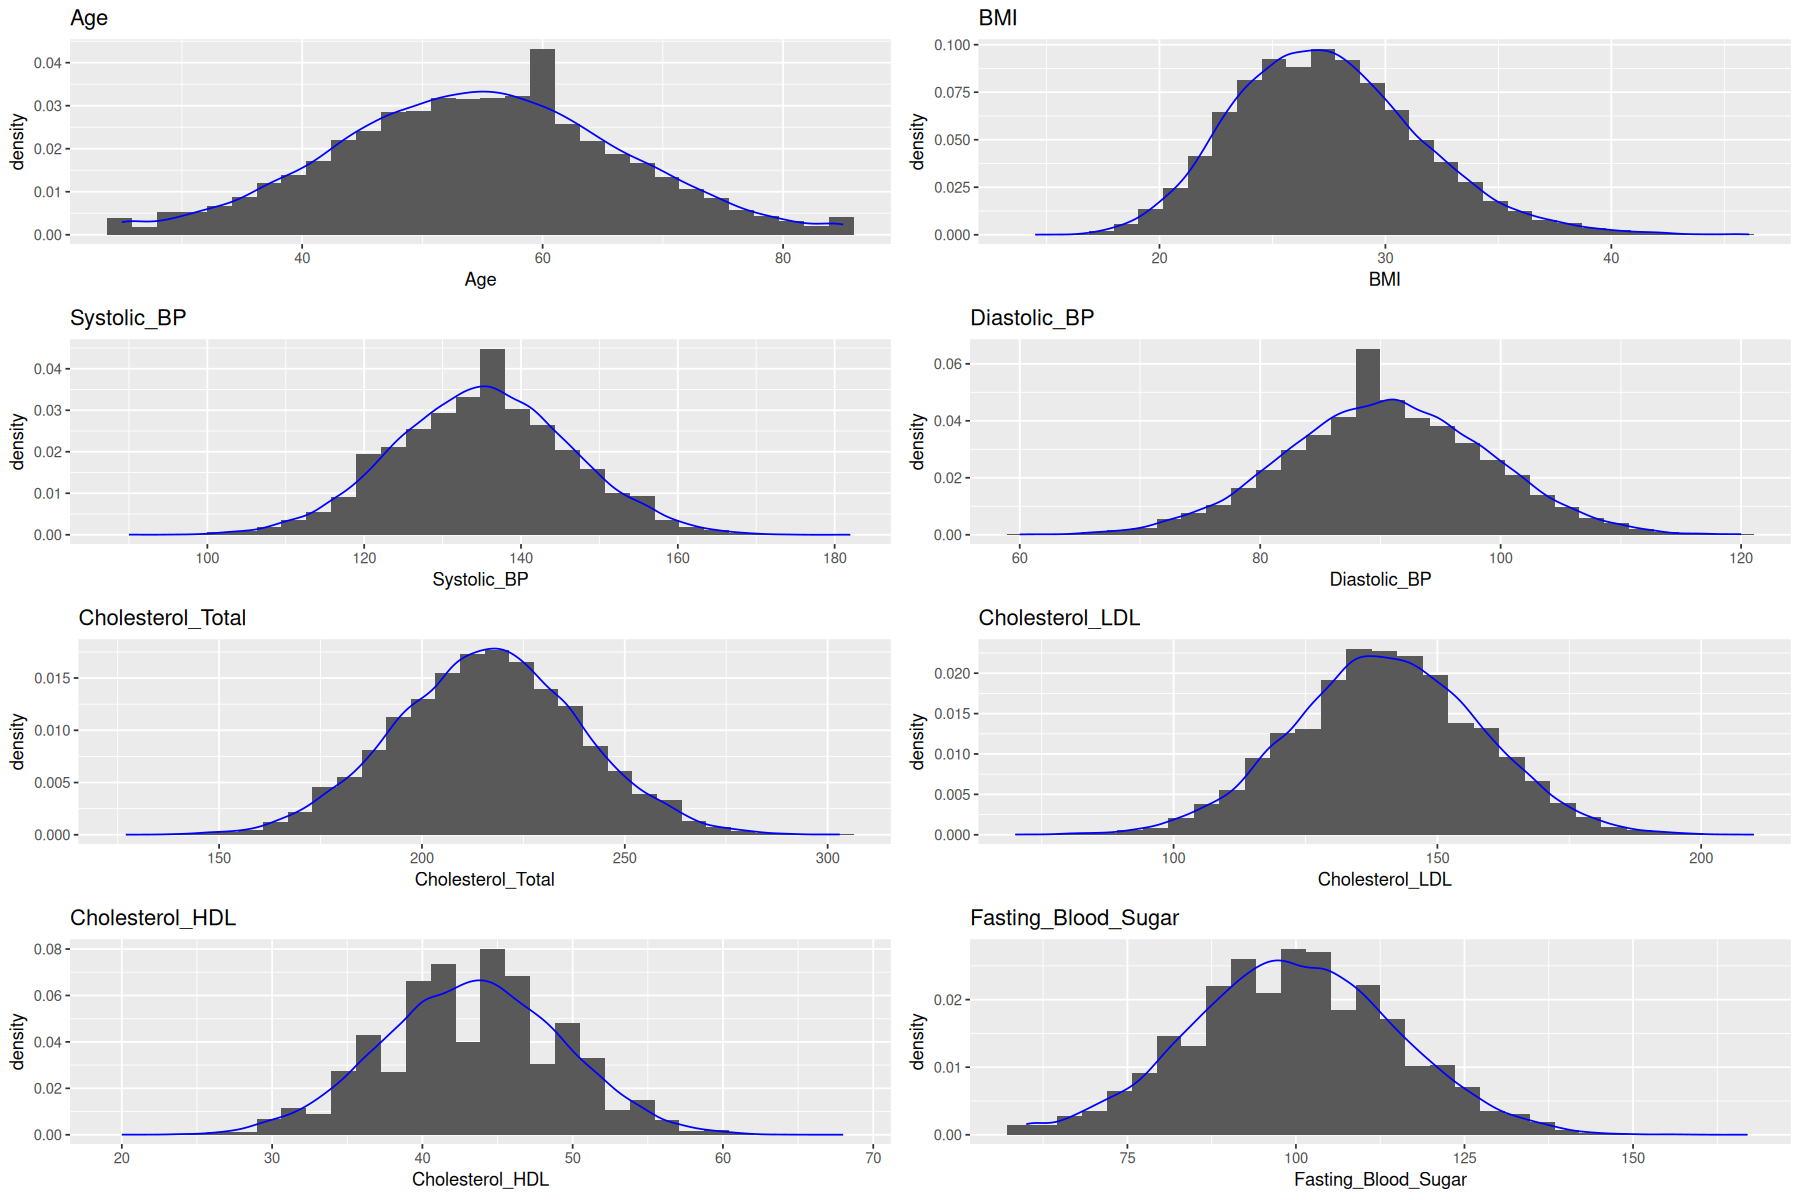

In [82]:
# Histogrammes des variables quantitaives

vars <- c("Age", "BMI", "Systolic_BP", "Diastolic_BP",
          "Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL",
          "Fasting_Blood_Sugar")

plots <- lapply(vars, function(v) {
  ggplot(data, aes_string(x = v)) +
    geom_histogram(aes(y = after_stat(density)), bins = 30) +
    geom_density(alpha = .2, col = "blue") +
    ggtitle(v)
})

grid.arrange(grobs = plots, ncol = 2)

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> On observe des densités symétriques (donc plutôt gaussiennes) cela sera nécessaire pour certaines méthodes à venir de modélisation (linéaires), mais pas pour toutes (arbres).
</div>

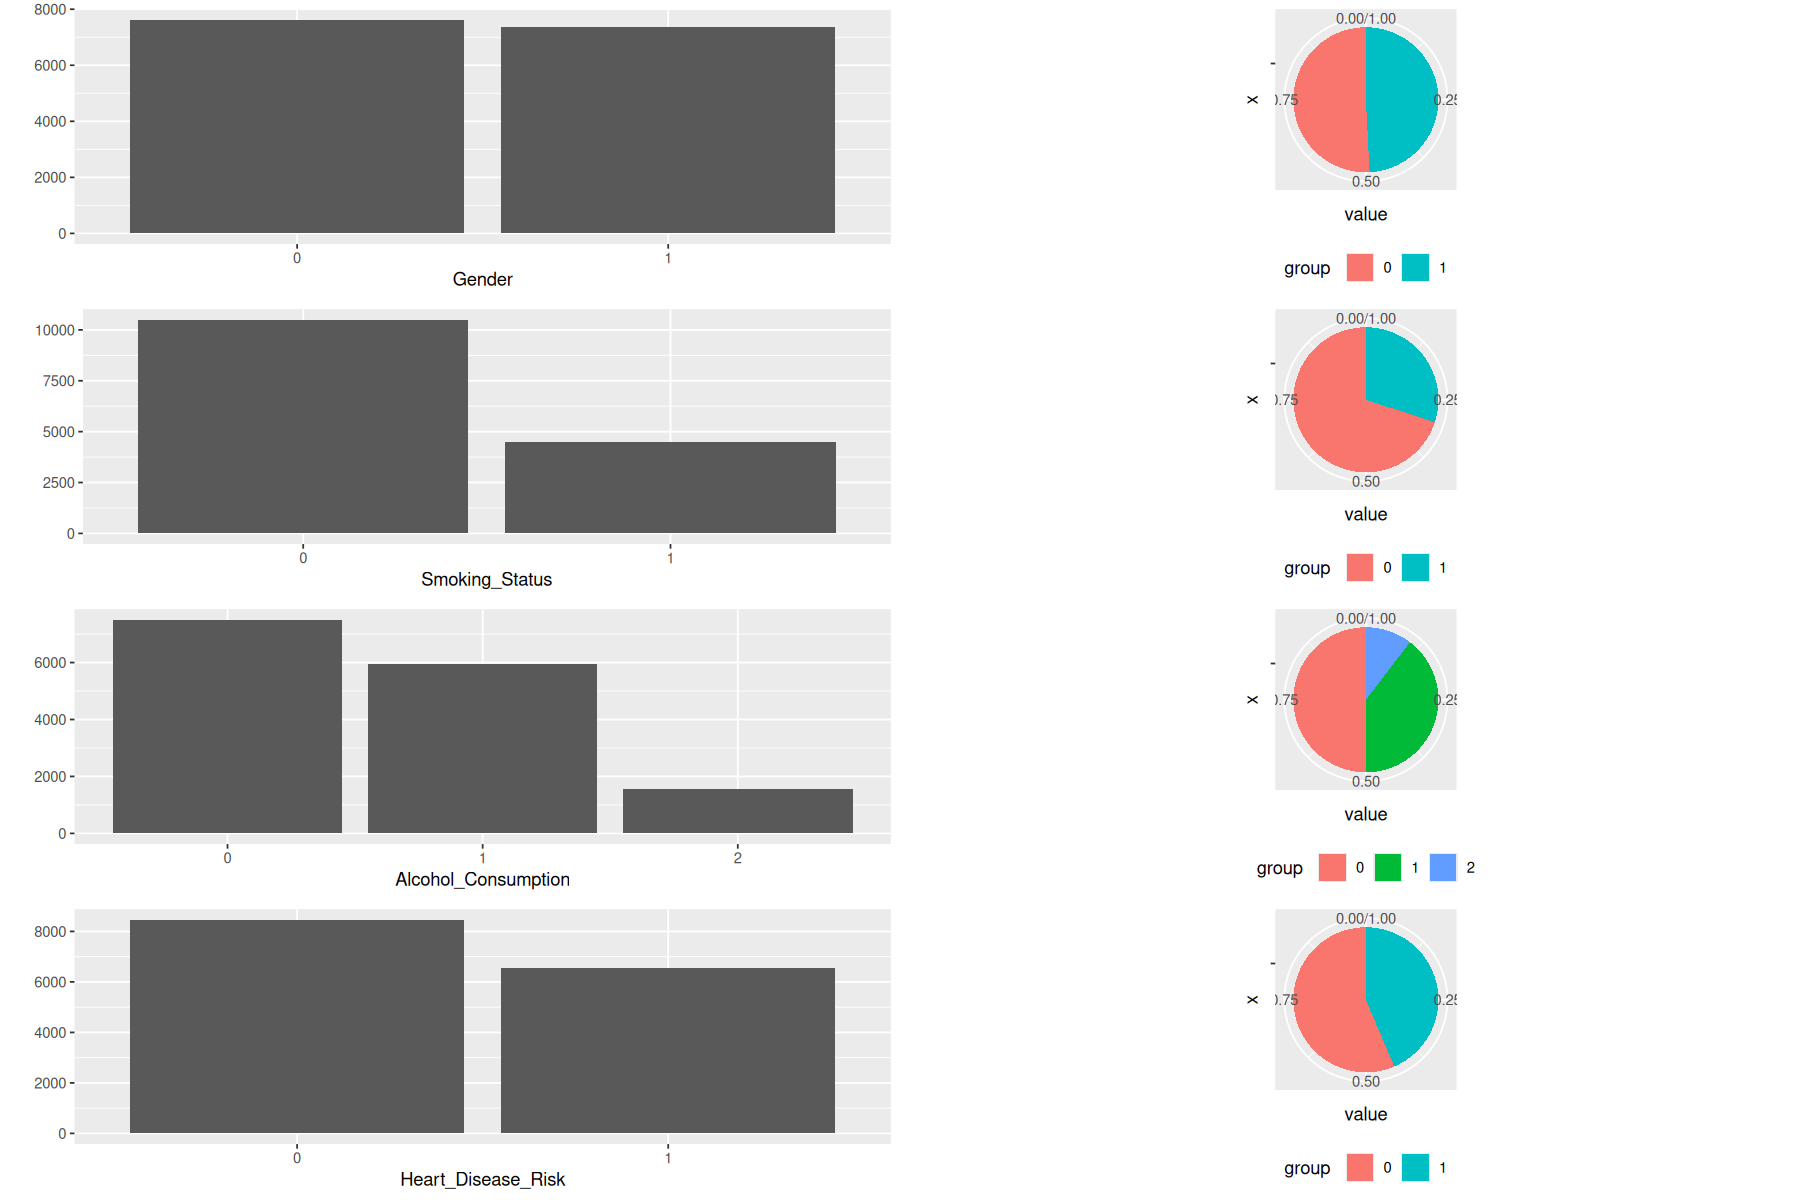

In [83]:
# Statistiques descriptives des variables qualitatives

# Gender
df1 <- data.frame(
  group = levels(as.factor(data$Gender)),
  value = as.vector(table(data$Gender)) / nrow(data)
)

g1 <- ggplot(data, aes(x = Gender)) + 
  geom_bar() +
  ylab("")

g2 <- ggplot(df1, aes(x = "", y = value, fill = group)) +
  geom_bar(width = 1, stat = "identity") + 
  coord_polar("y", start = 0) + 
  theme(legend.position = "bottom")

# Smoking_Status
df2 <- data.frame(
  group = levels(as.factor(data$Smoking_Status)),
  value = as.vector(table(data$Smoking_Status)) / nrow(data)
)

g3 <- ggplot(data, aes(x = Smoking_Status)) + 
  geom_bar() +
  ylab("")

g4 <- ggplot(df2, aes(x = "", y = value, fill = group)) +
  geom_bar(width = 1, stat = "identity") + 
  coord_polar("y", start = 0) + 
  theme(legend.position = "bottom")

# Alcohol_Consumption
df3 <- data.frame(
  group = levels(as.factor(data$Alcohol_Consumption)),
  value = as.vector(table(data$Alcohol_Consumption)) / nrow(data)
)

g5 <- ggplot(data, aes(x = Alcohol_Consumption)) + 
  geom_bar() +
  ylab("")

g6 <- ggplot(df3, aes(x = "", y = value, fill = group)) +
  geom_bar(width = 1, stat = "identity") + 
  coord_polar("y", start = 0) + 
  theme(legend.position = "bottom")

# Heart_Disease_Risk
df4 <- data.frame(
  group = levels(as.factor(data$Heart_Disease_Risk)),
  value = as.vector(table(data$Heart_Disease_Risk)) / nrow(data)
)

g7 <- ggplot(data, aes(x = Heart_Disease_Risk)) + 
  geom_bar() +
  ylab("")

g8 <- ggplot(df4, aes(x = "", y = value, fill = group)) +
  geom_bar(width = 1, stat = "identity") + 
  coord_polar("y", start = 0) + 
  theme(legend.position = "bottom")

# Affichage
grid.arrange(g1, g2, g3, g4, g5, g6, g7, g8, ncol = 2)

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> La variable genre est équilibrée mais les variables Alcohol_Consumption et Smoking_Status sont fortement déséquilibrées. La variable Heart_Disease_Risk est ??? 
</div>

### Analyse descriptive bidimensionnelles


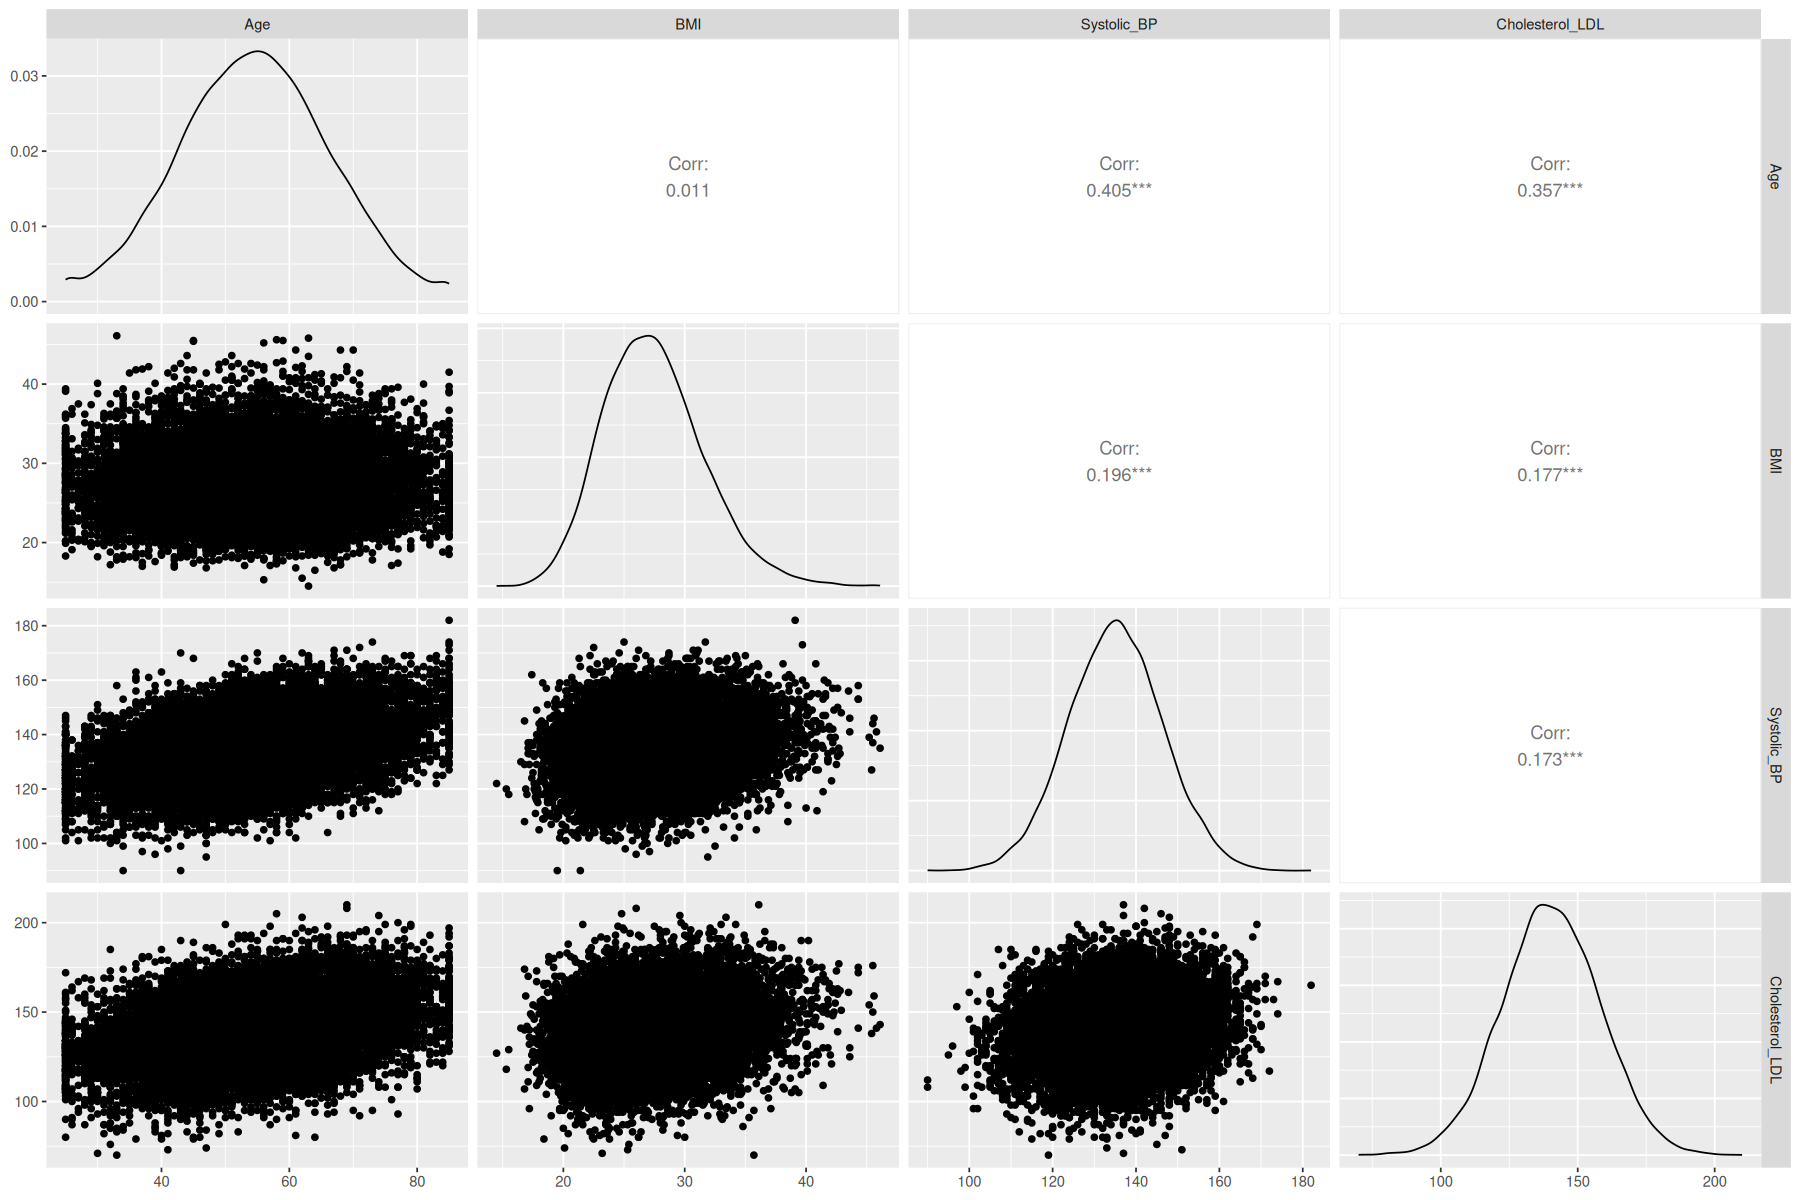

In [84]:
# Corrélations des variables quantitatives

ggpairs(data[, c("Age", "BMI", "Systolic_BP", "Cholesterol_LDL")])

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> La plus forte corrélation observée est entre l'âge et la pression artérielle systolique (Systolic_BP), puis entre l'âge et la quantité de lipoprotéines de basse densité "mauvais cholestérol (Cholesterol_LDL).
</div>

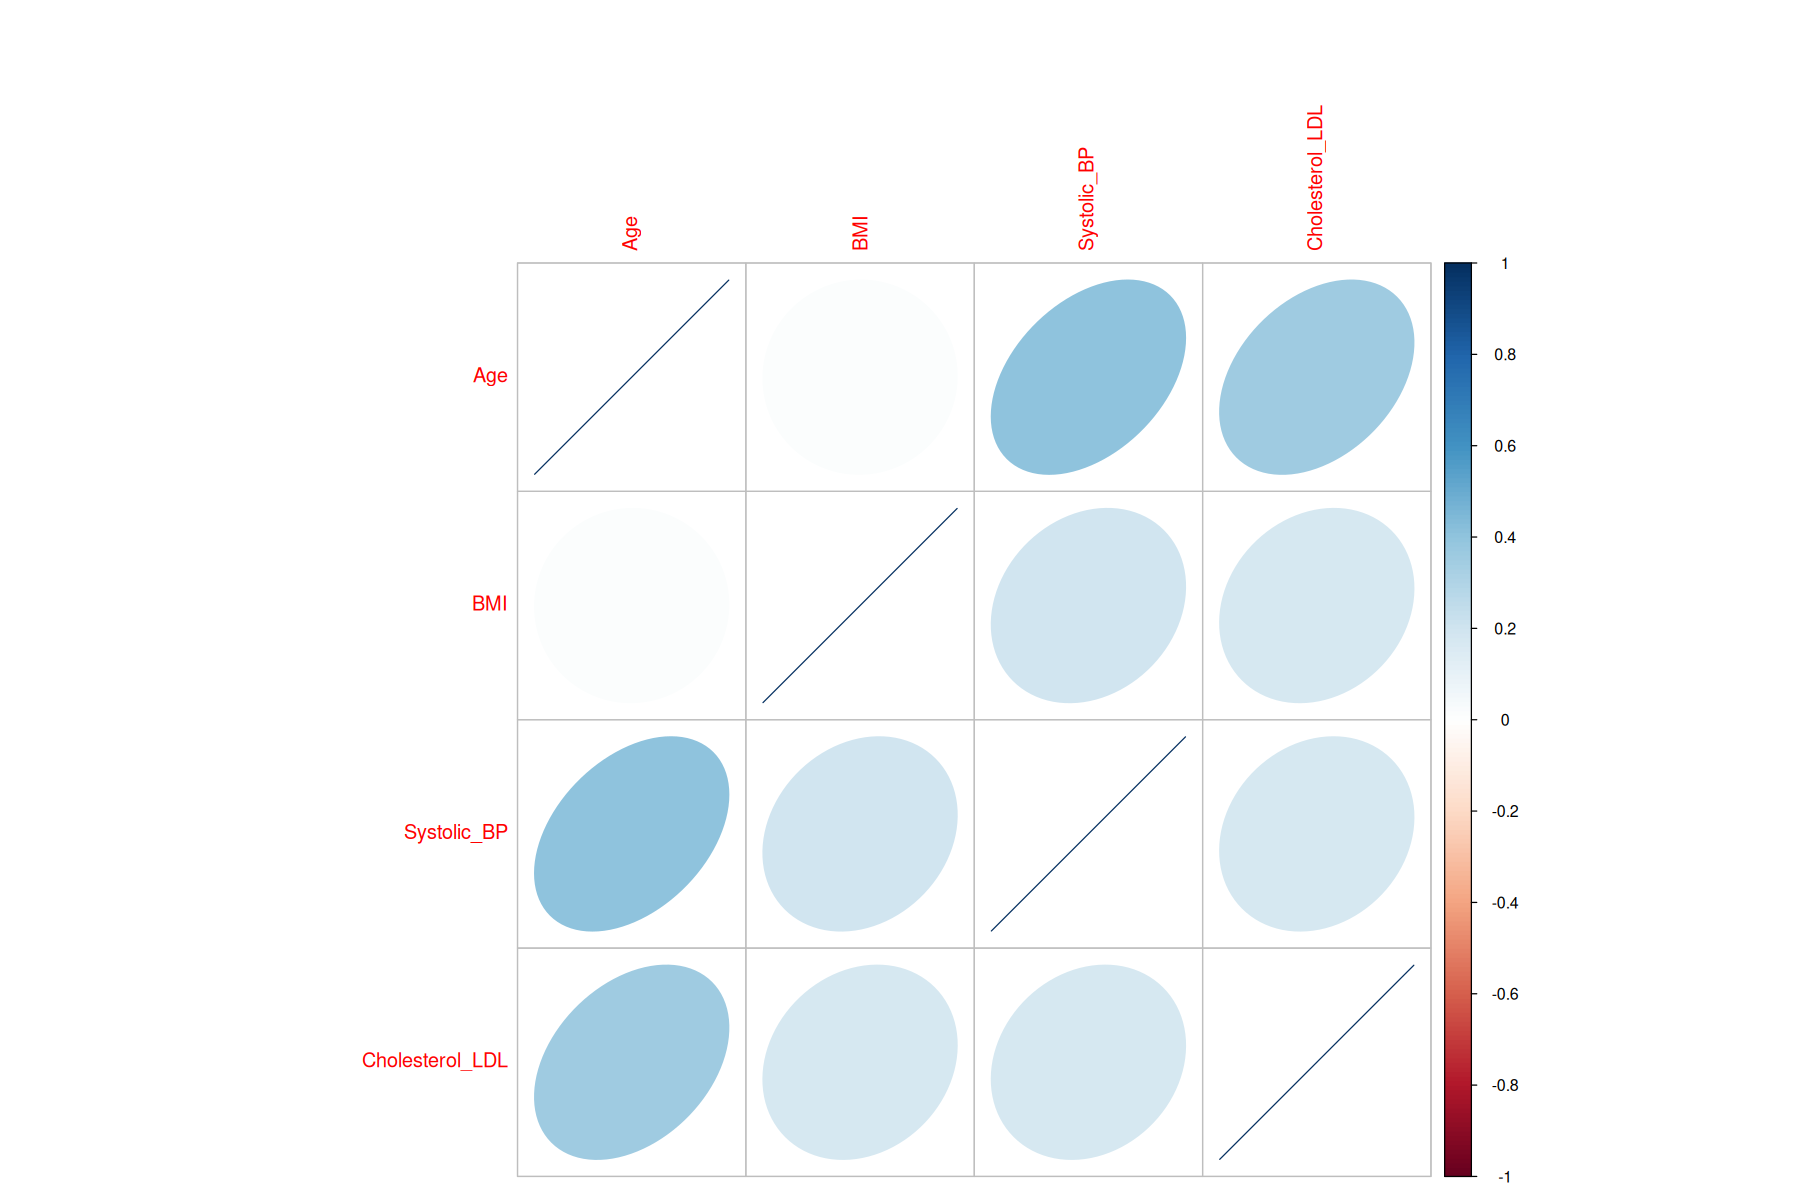

In [85]:
# On fait la même chose avec corrplot pour comparer

corrplot(cor(data[, c("Age", "BMI", "Systolic_BP", "Cholesterol_LDL")]),method="ellipse")

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> Attention, ici on ne mesure que des corrélations linéaires entre les variables quantitatives. Pour étudier la corrélation entre les variables quantitatives et qualitatives il faut calculer le coefficient "éta carré".
</div>

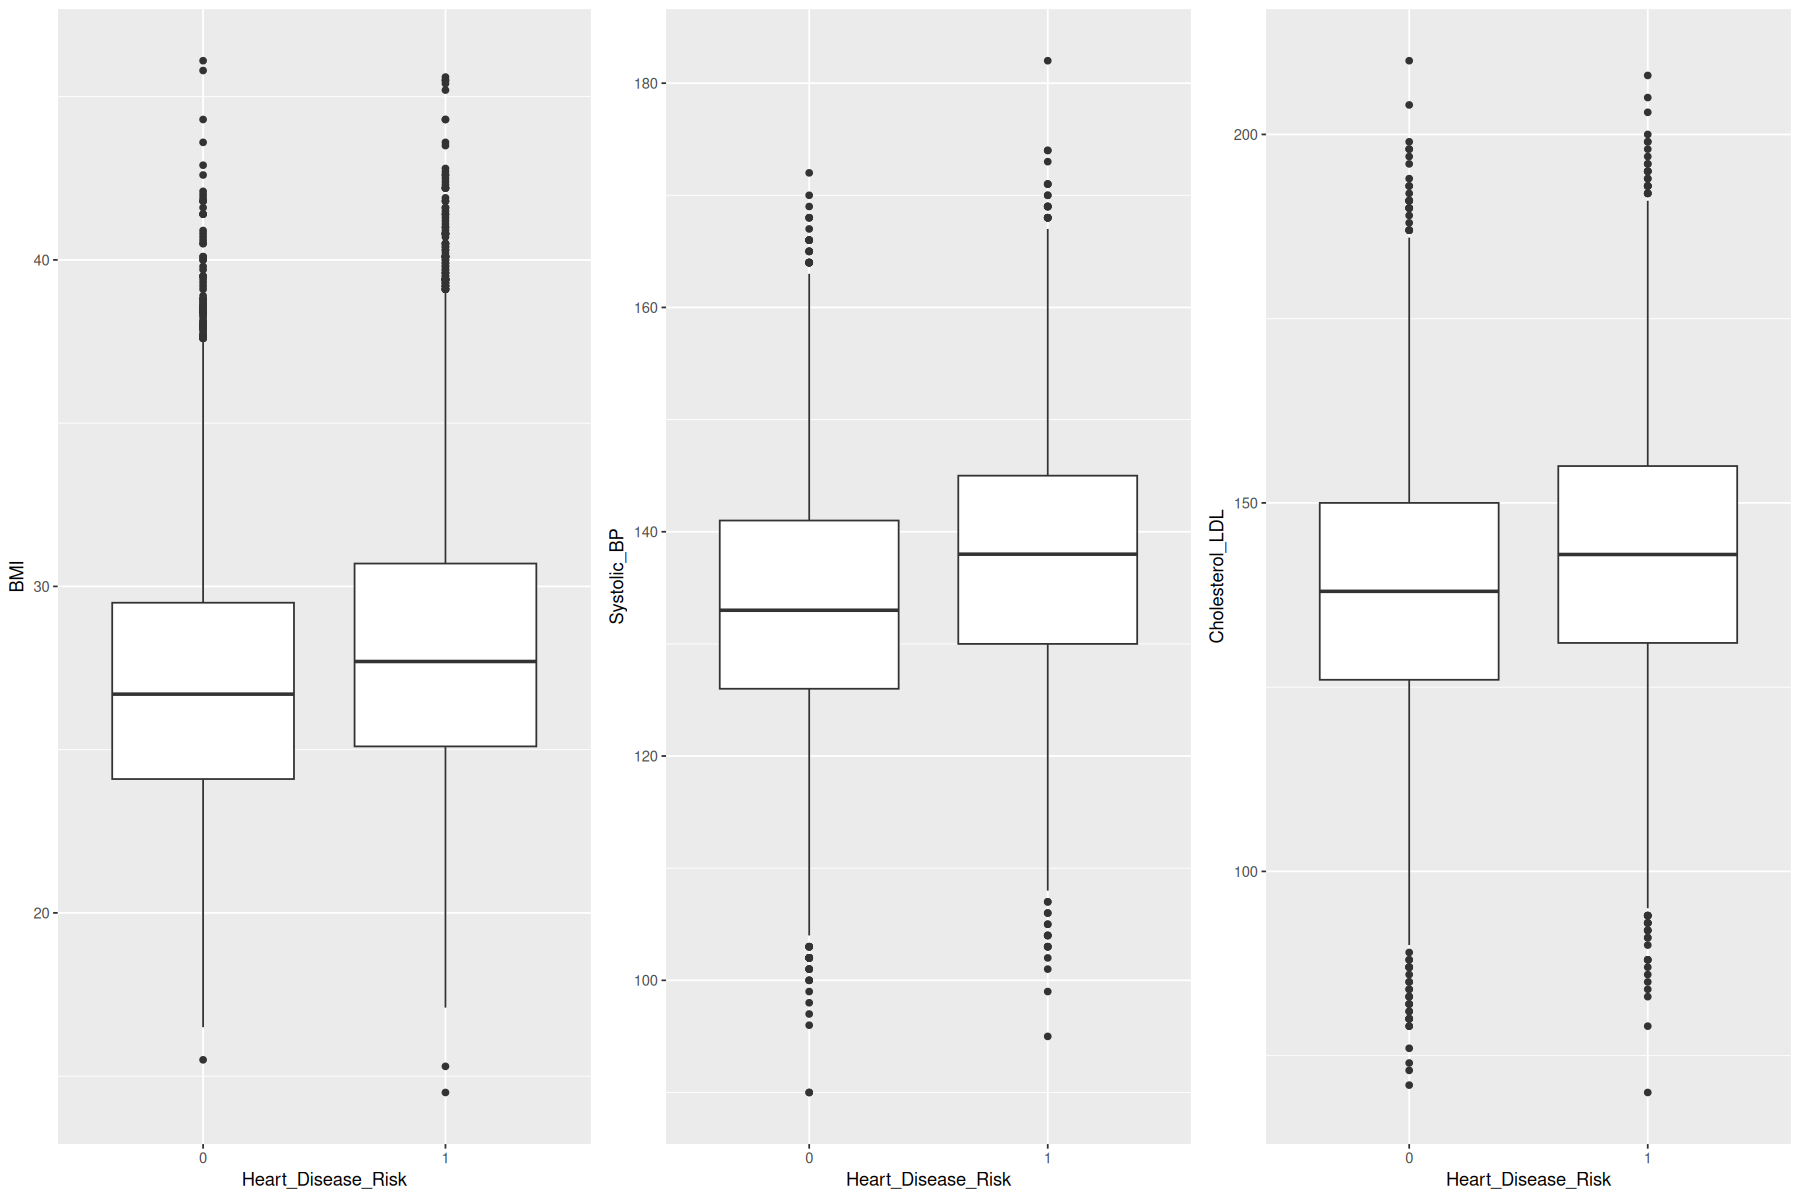

In [86]:
# Analyse bidimensionnelle des variables quantitatives et qualitatives

g1 <- ggplot(data, aes(x = Heart_Disease_Risk, y = BMI)) +
  geom_boxplot()

g2 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Systolic_BP)) +
  geom_boxplot()

g3 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Cholesterol_LDL)) +
  geom_boxplot()

grid.arrange(g1, g2, g3, ncol = 3)

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> Ici on regarde le risque d’accident cardiaque en fonction de 3 variables : l'indice de masse corporelle (BMI), la pression artérielle systolique (Systolic_BP) et la quantité de lipoprotéines de basse densité "mauvais cholestérol" (Cholesterol_LDL). On observe pas de forte corrélation avec l'une de ces variables.
</div>

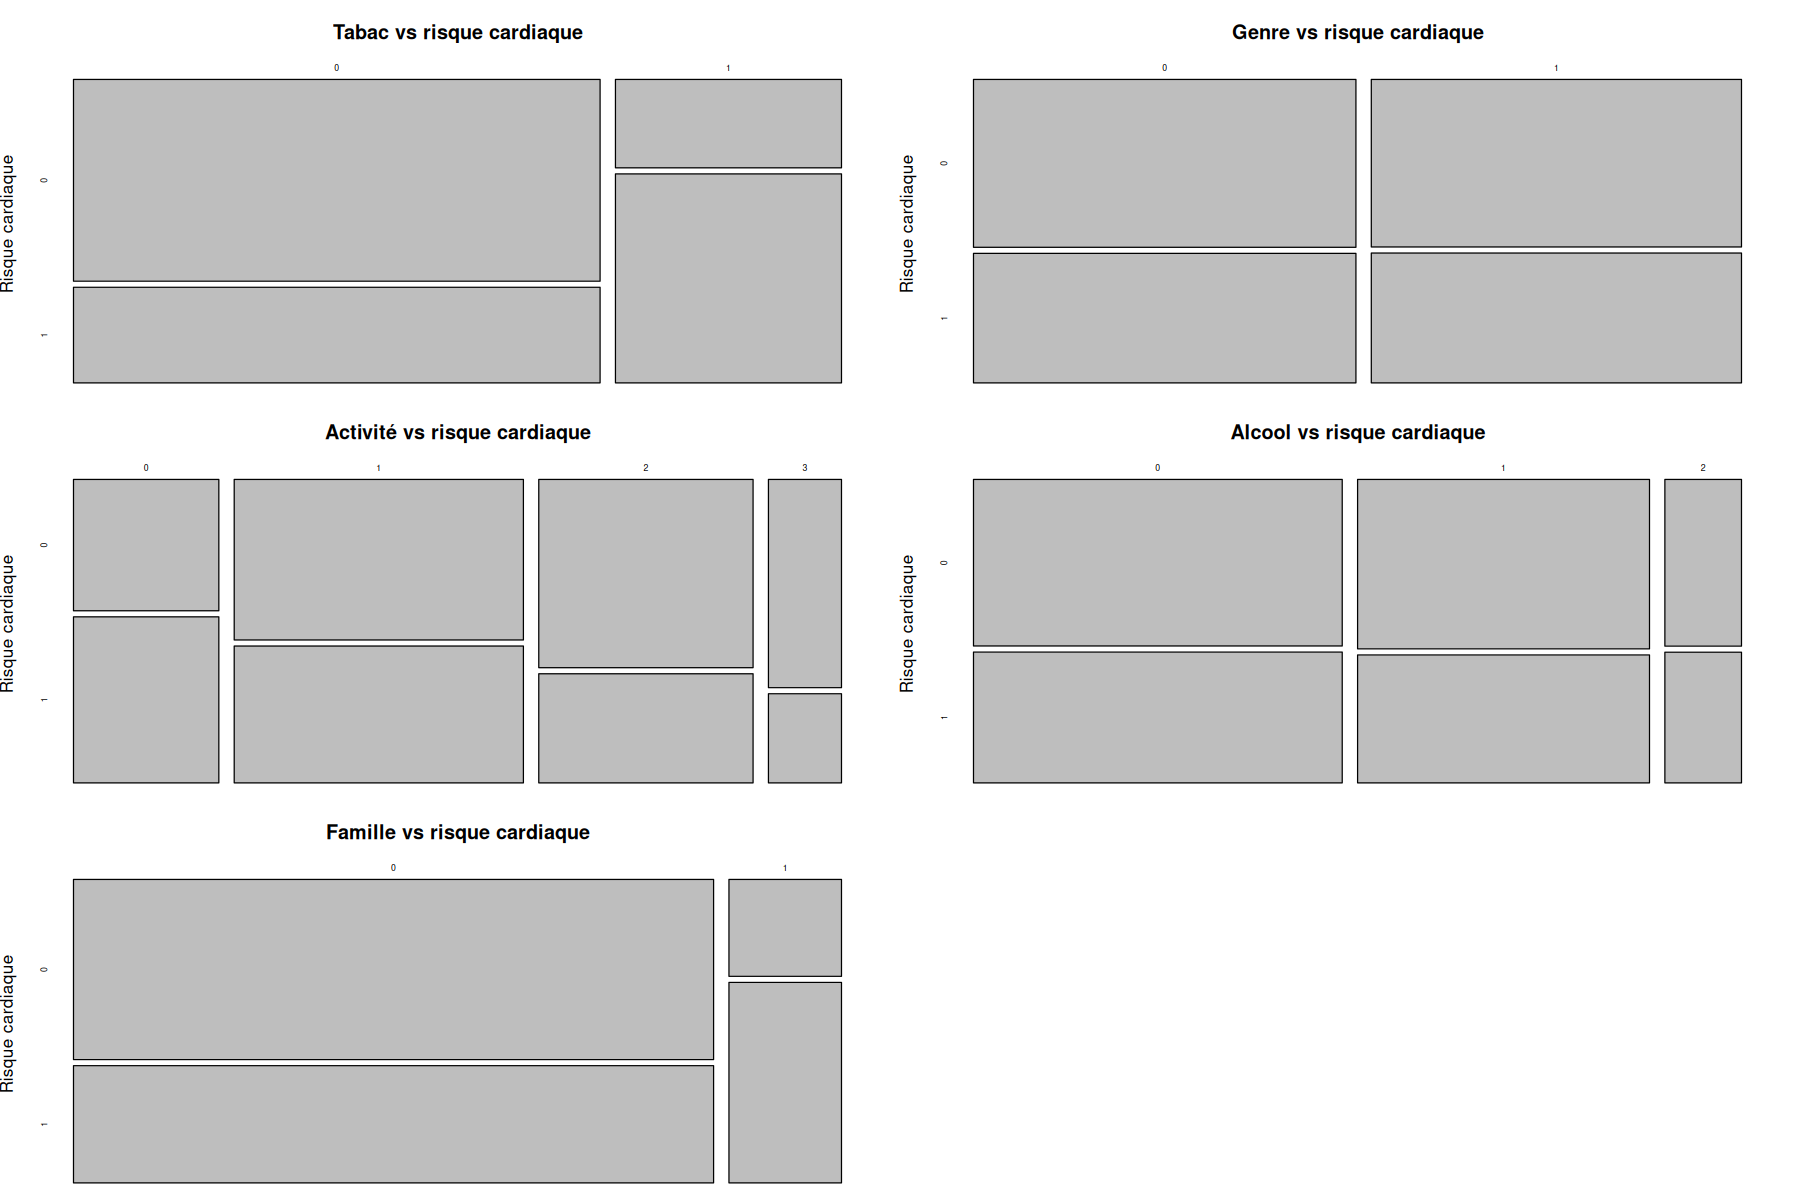

In [87]:
# Mettre 2 lignes et 3 colonnes pour afficher plusieurs plots sur une seule fenêtre
par(mfrow = c(3, 2), mar = c(1, 2, 4, 1), cex.axis = 1.2, cex.lab = 1.3, cex.main = 1.5) # 'mar' ajuste les marges pour que ce soit plus compact

# Mosaic plots
mosaicplot(
  table(data$Smoking_Status, data$Heart_Disease_Risk),
  xlab = "Statut tabagisme",
  ylab = "Risque cardiaque",
  main = "Tabac vs risque cardiaque"
)

mosaicplot(
  table(data$Gender, data$Heart_Disease_Risk),
  xlab = "Genre",
  ylab = "Risque cardiaque",
  main = "Genre vs risque cardiaque"
)

mosaicplot(
  table(data$Physical_Activity_Level, data$Heart_Disease_Risk),
  xlab = "Activité physique",
  ylab = "Risque cardiaque",
  main = "Activité vs risque cardiaque"
)

mosaicplot(
  table(data$Alcohol_Consumption, data$Heart_Disease_Risk),
  xlab = "Consommation alcool",
  ylab = "Risque cardiaque",
  main = "Alcool vs risque cardiaque"
)

mosaicplot(
  table(data$Family_History, data$Heart_Disease_Risk),
  xlab = "Histoire familiale",
  ylab = "Risque cardiaque",
  main = "Famille vs risque cardiaque"
)

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> On observe que les non-fumeurs ont majoritairement un faible risque cardiaque, tandis que les fumeurs présentent une proportion plus grande de risque élevé, ce qui est cohérent avec les effets connus du tabac sur la santé cardiovasculaire. La variable décrivant l'histoire familiale se comporte de la même façon : les personnes ayant des antécédents familiaux de maladie cardiaque présentent une proportion plus grande de risque élevé.
    Le genre et la consommation d'alcool ne semblent pas corrélés au risque cardiaque. 
    Le niveau d'activité physique semble corrélé linéairement au risuqe cardiaque.  
</div>

### ACP

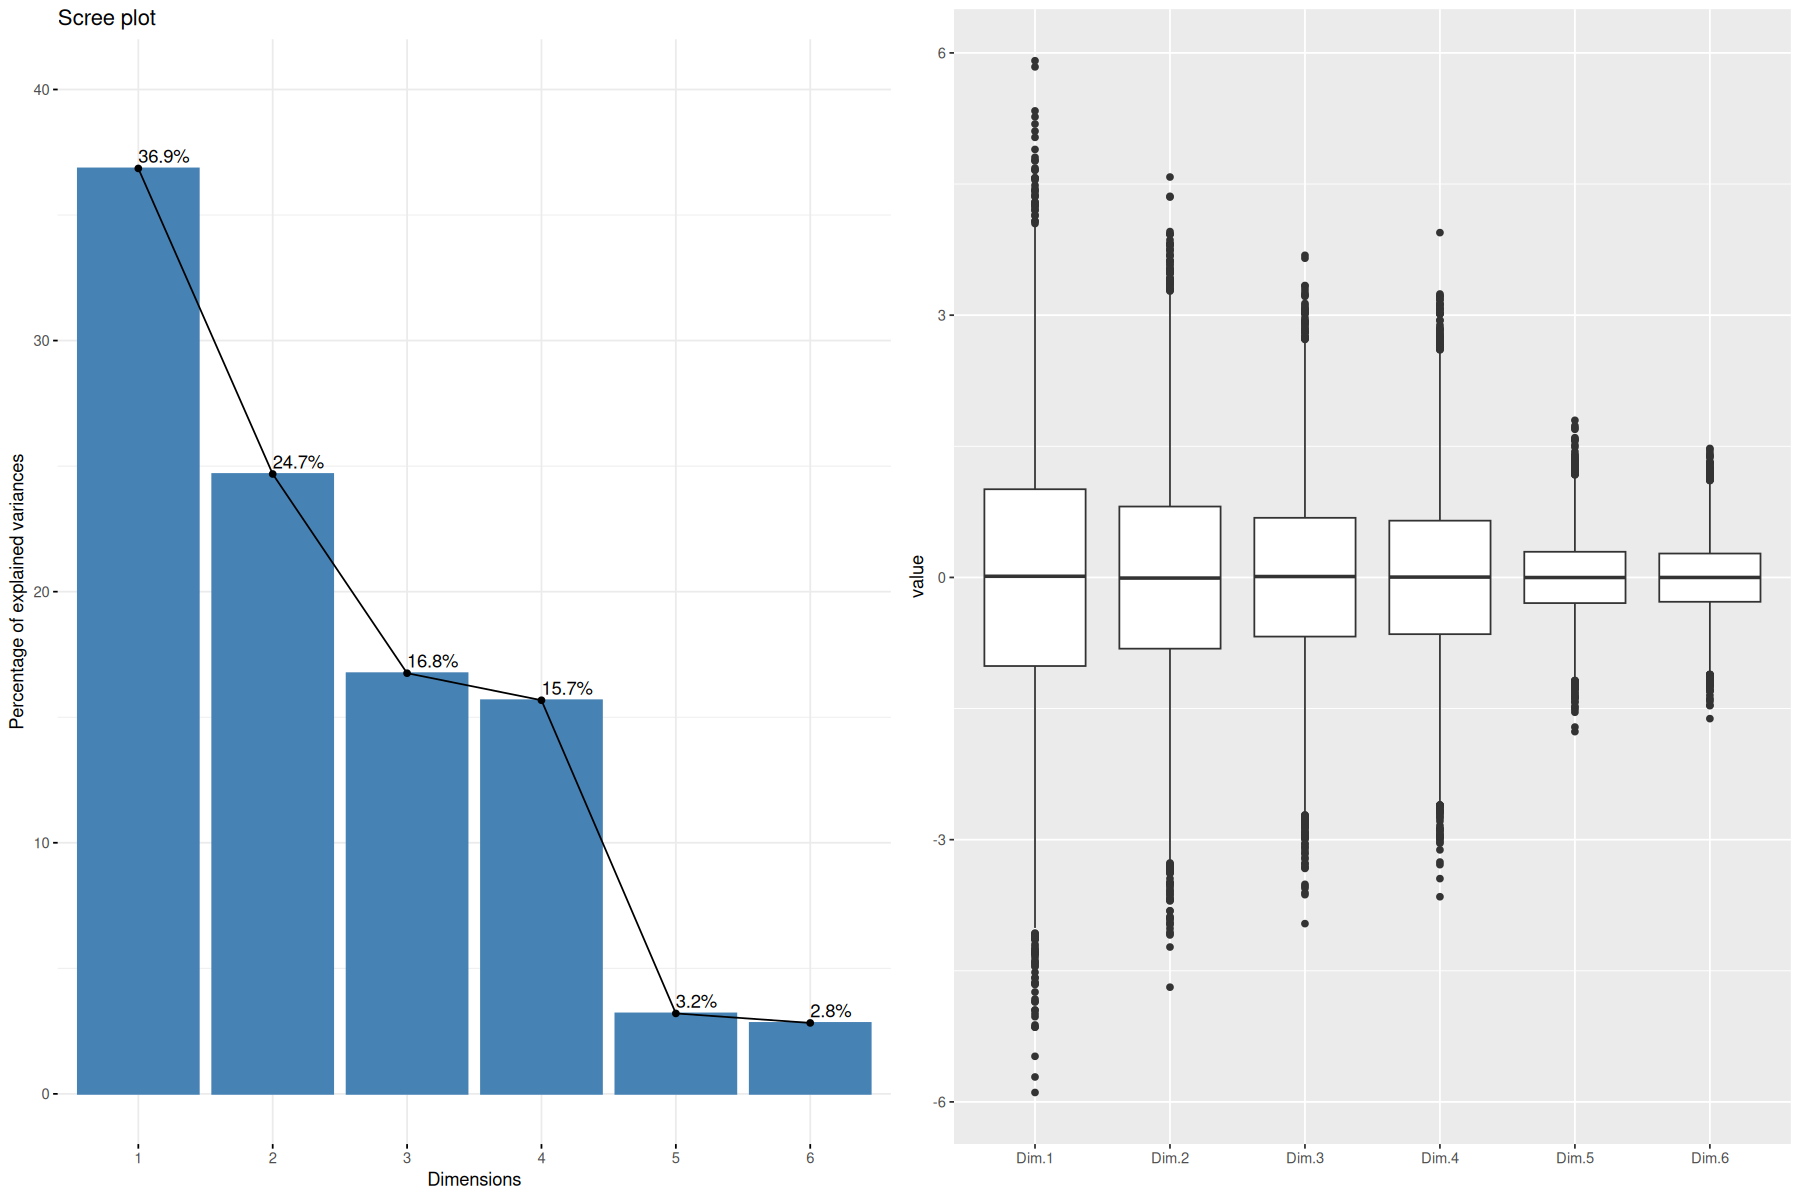

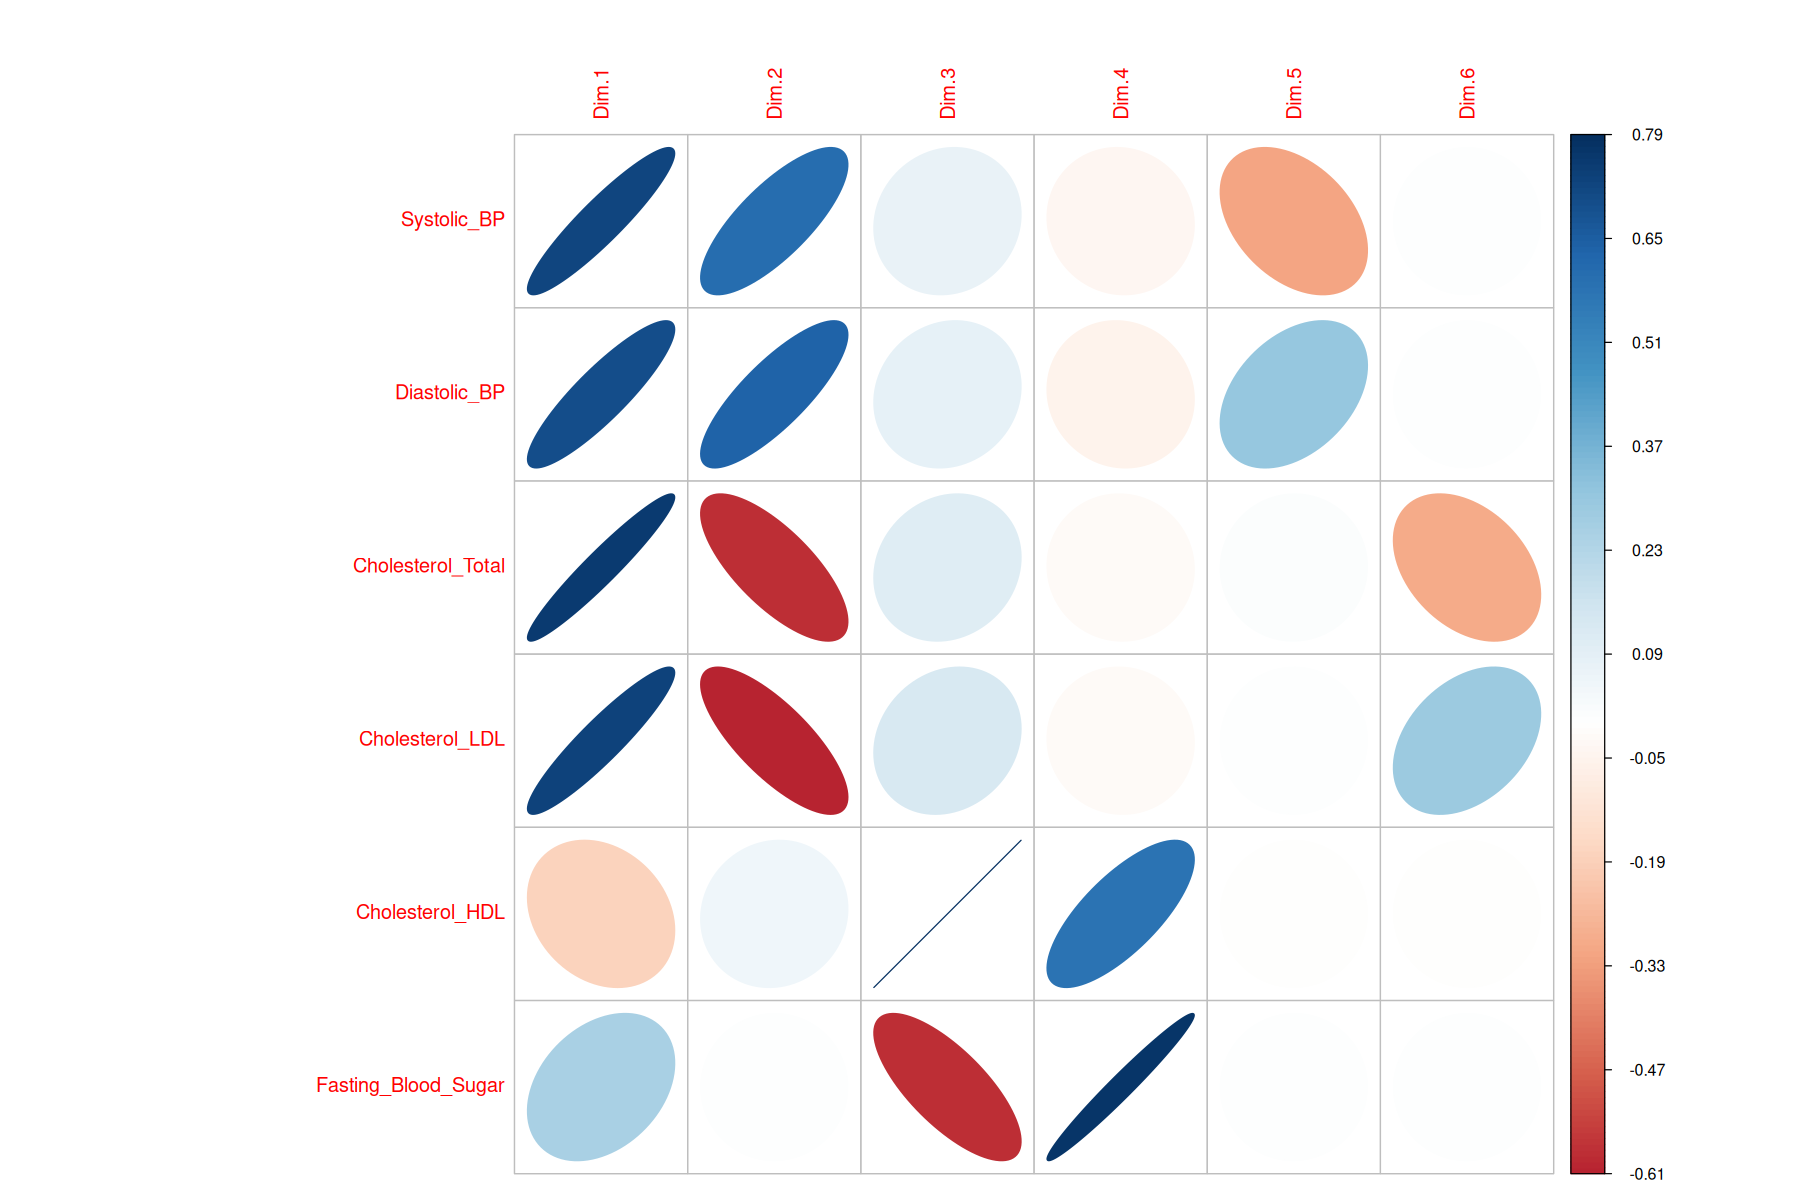

In [88]:
# ACP sur les variables quantitatives. Par ailleurs la variable à modéliser (Heart_Disease_Risk) n'est pas utilisée.

acp <- PCA(data[, c("Age", "BMI", "Systolic_BP", "Diastolic_BP",
          "Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL",
          "Fasting_Blood_Sugar")], scale.unit = TRUE,
           graph = FALSE, quali.sup = 1, quanti.sup = 2, ncp = 7)
# Décroissance des valeurs propres
library(factoextra)
g1<-fviz_eig(acp, addlabels = TRUE, ylim = c(0, 40))
library(reshape2)
g2<-ggplot(melt(acp$ind$coord),aes(x=Var2,y=value))+
  geom_boxplot()+
  xlab("")
grid.arrange(g1,g2,ncol=2)

corrplot(acp$var$cor, is.corr=FALSE,method="ellipse")

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b>  Ici la première composante principale représente 36.9% des données. D'après le coude observé sur le premier garphe on pourrait garder 2 ou 4 dimensions. Les 4 variables : "Systolic_BP", "Diastolic_BP", "Cholesterol_Total" et "Cholesterol_LDL" semblent fortement corrélées à la dimension 1. 
</div>

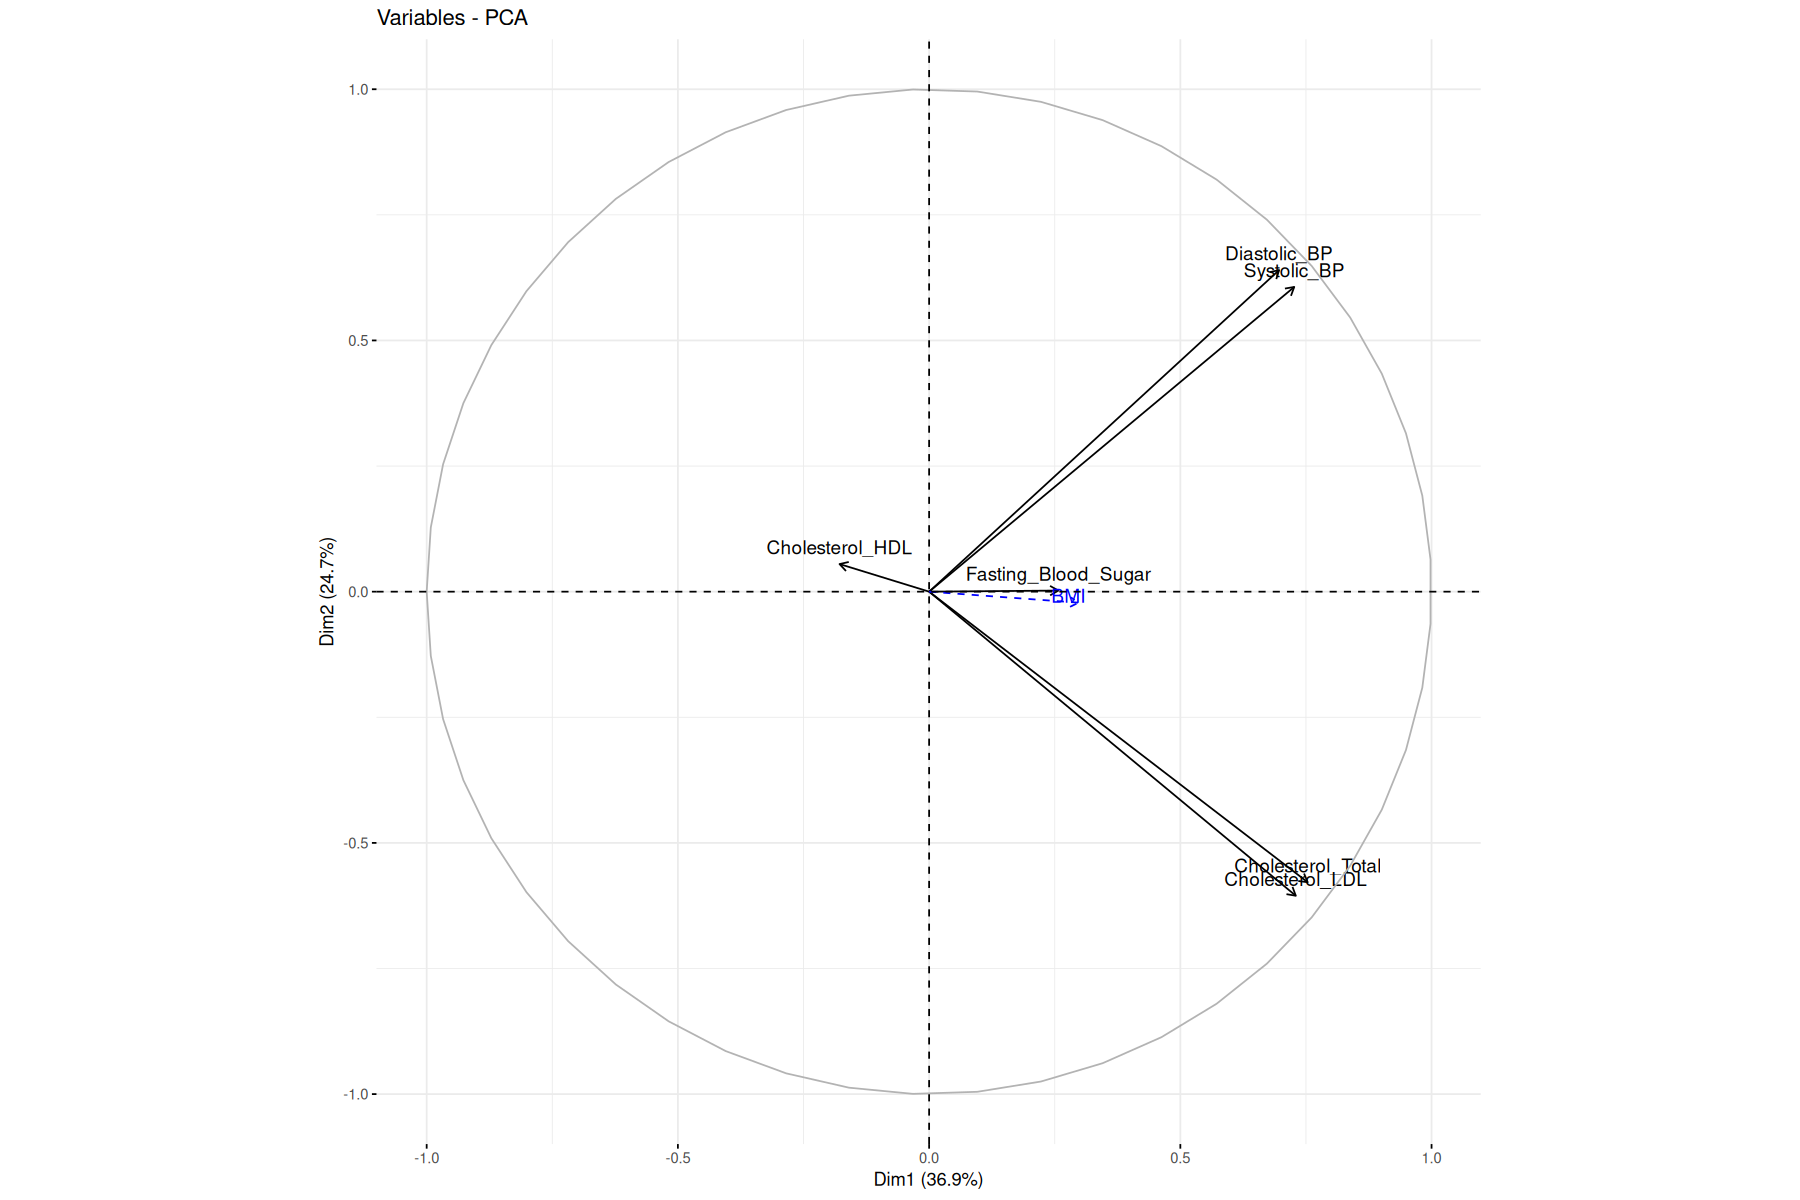

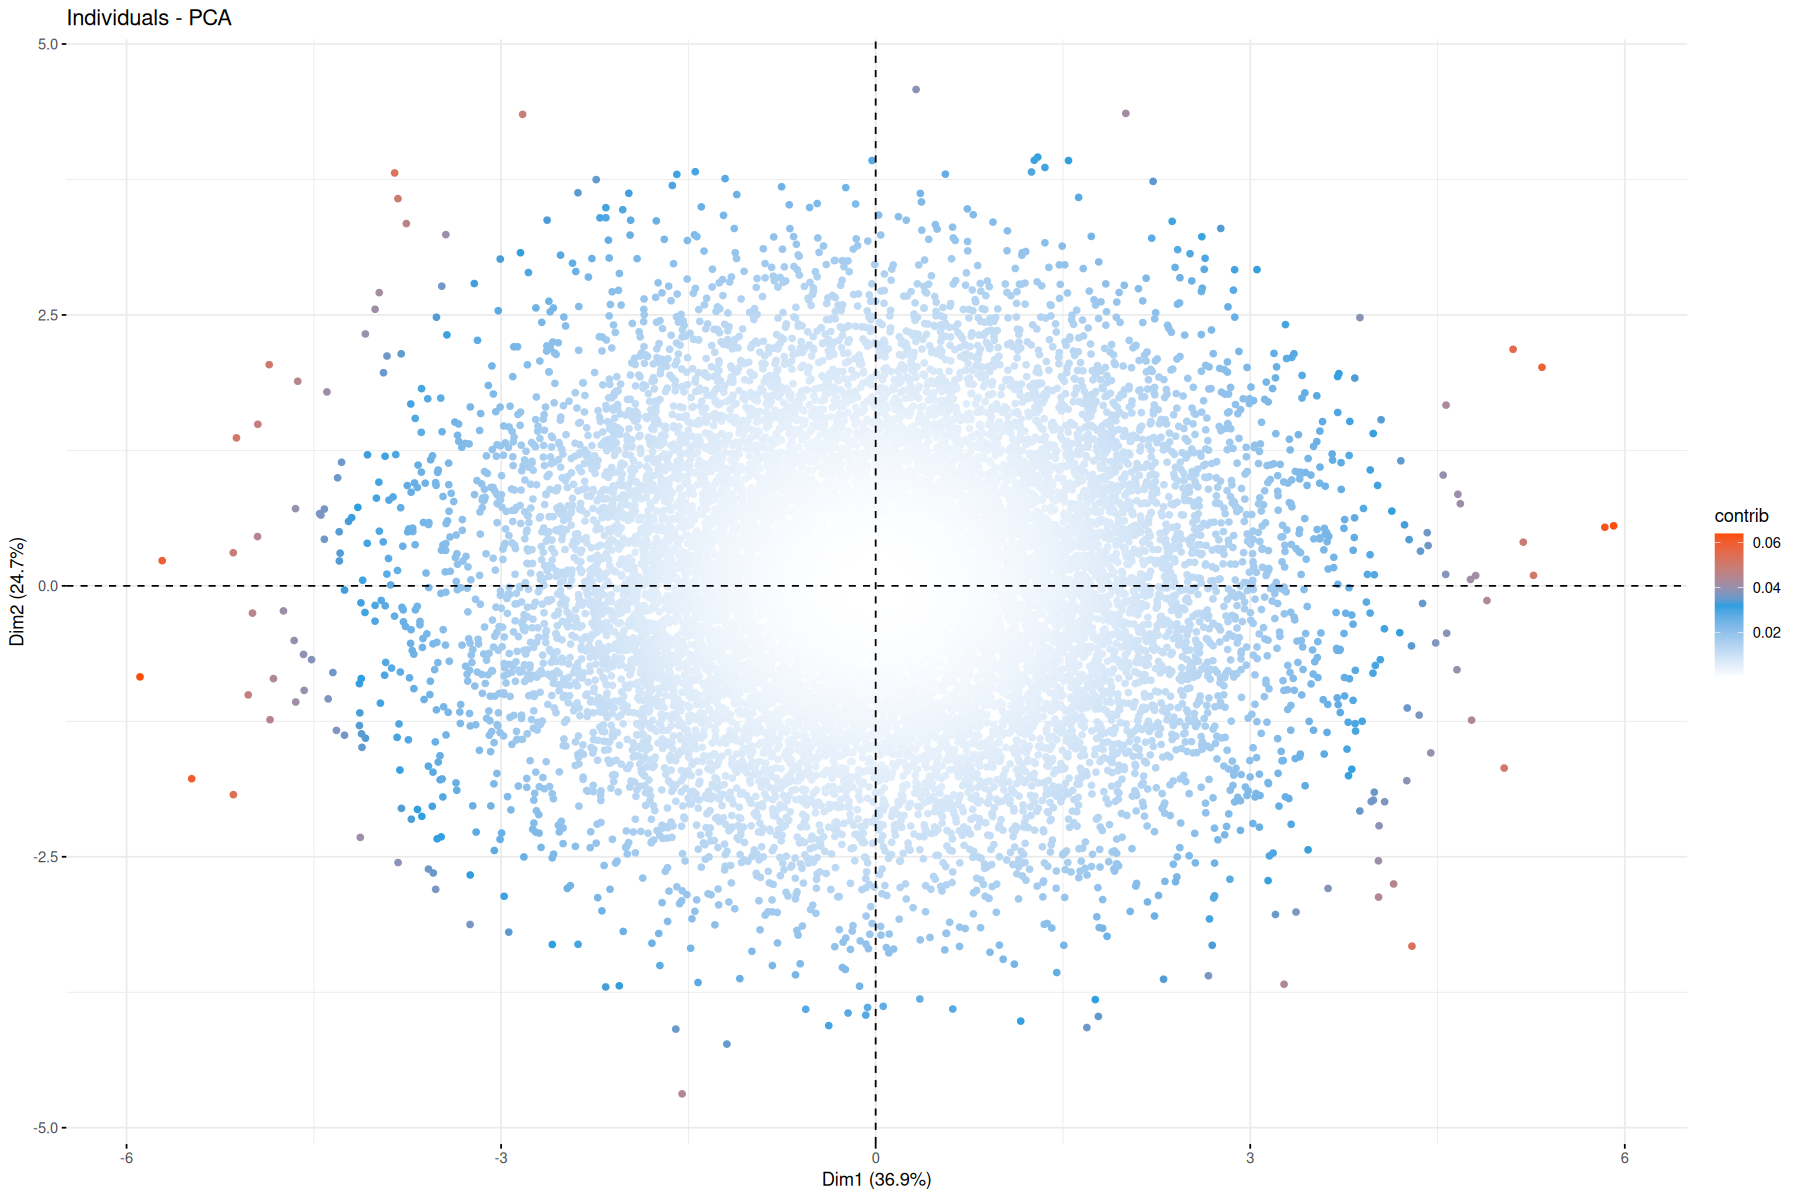

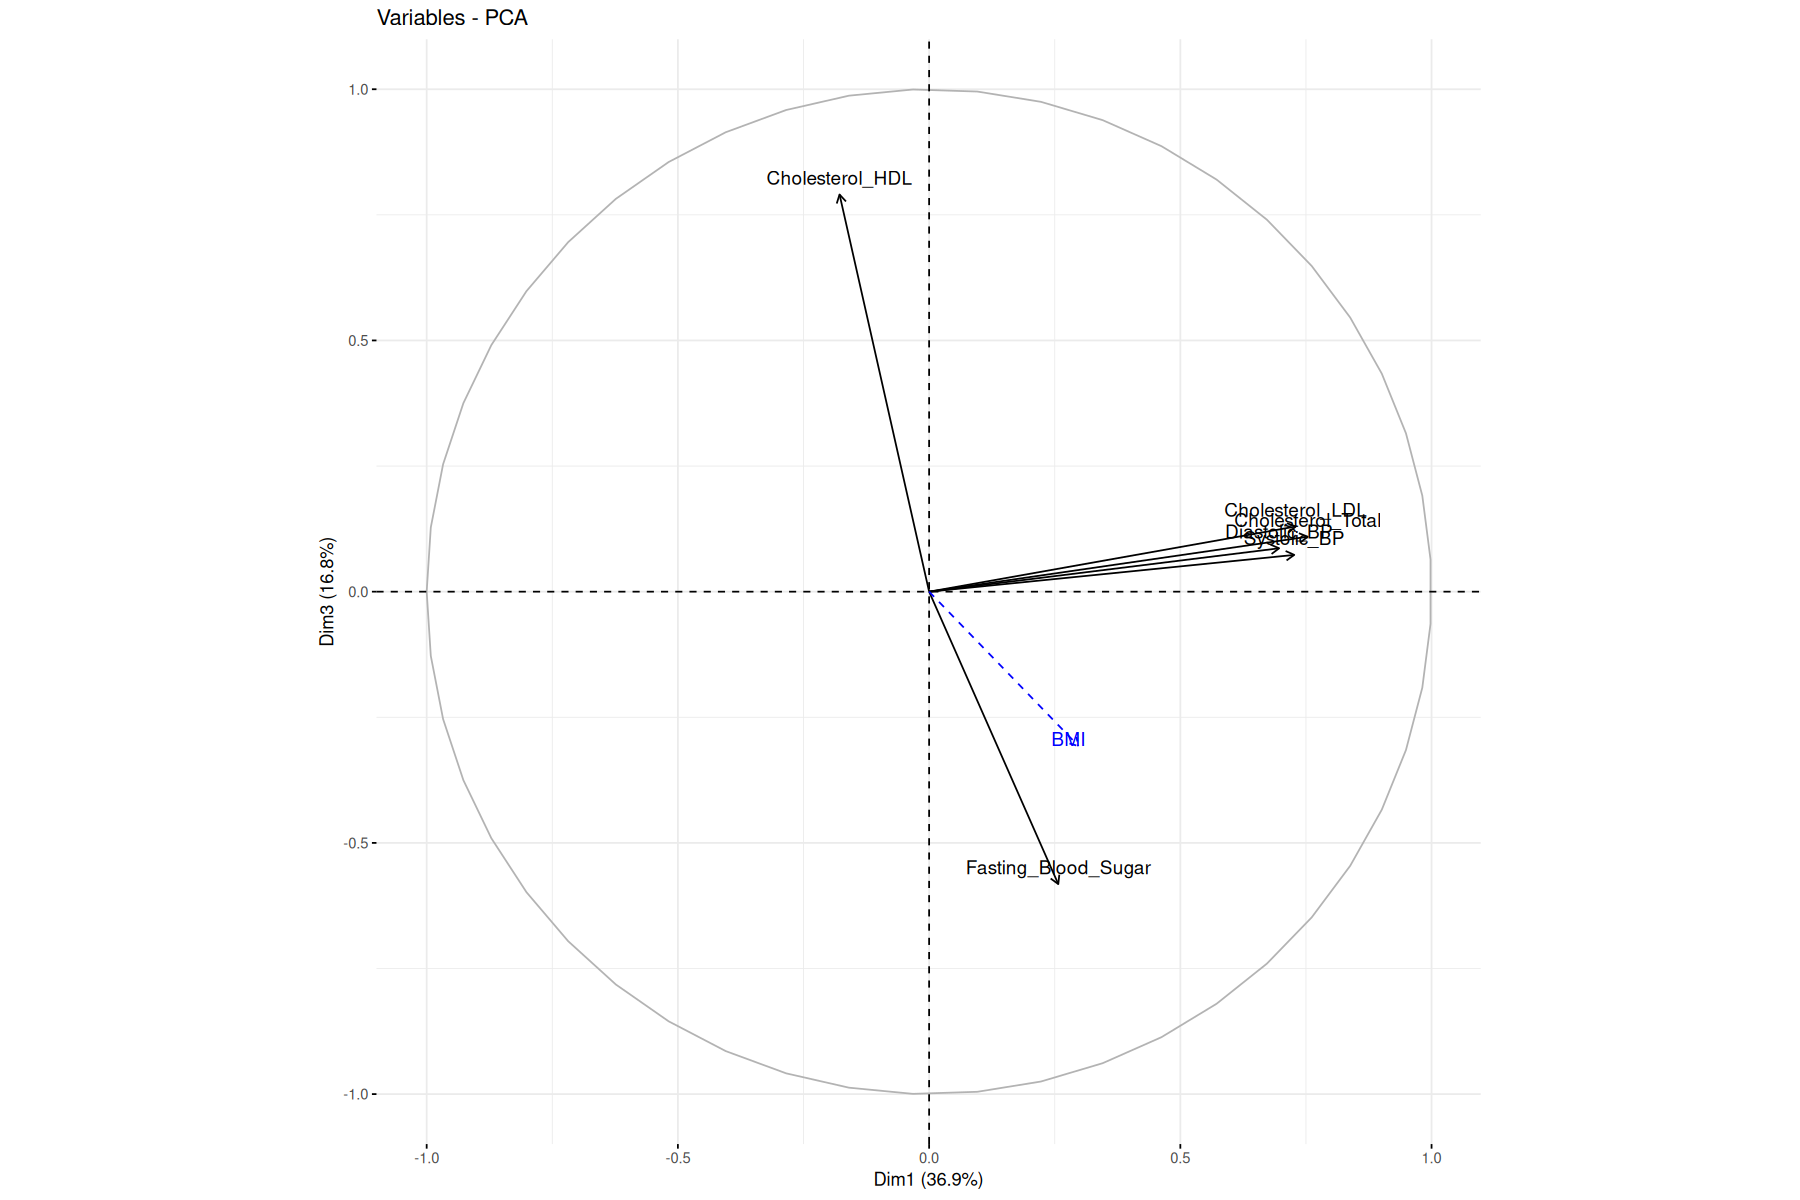

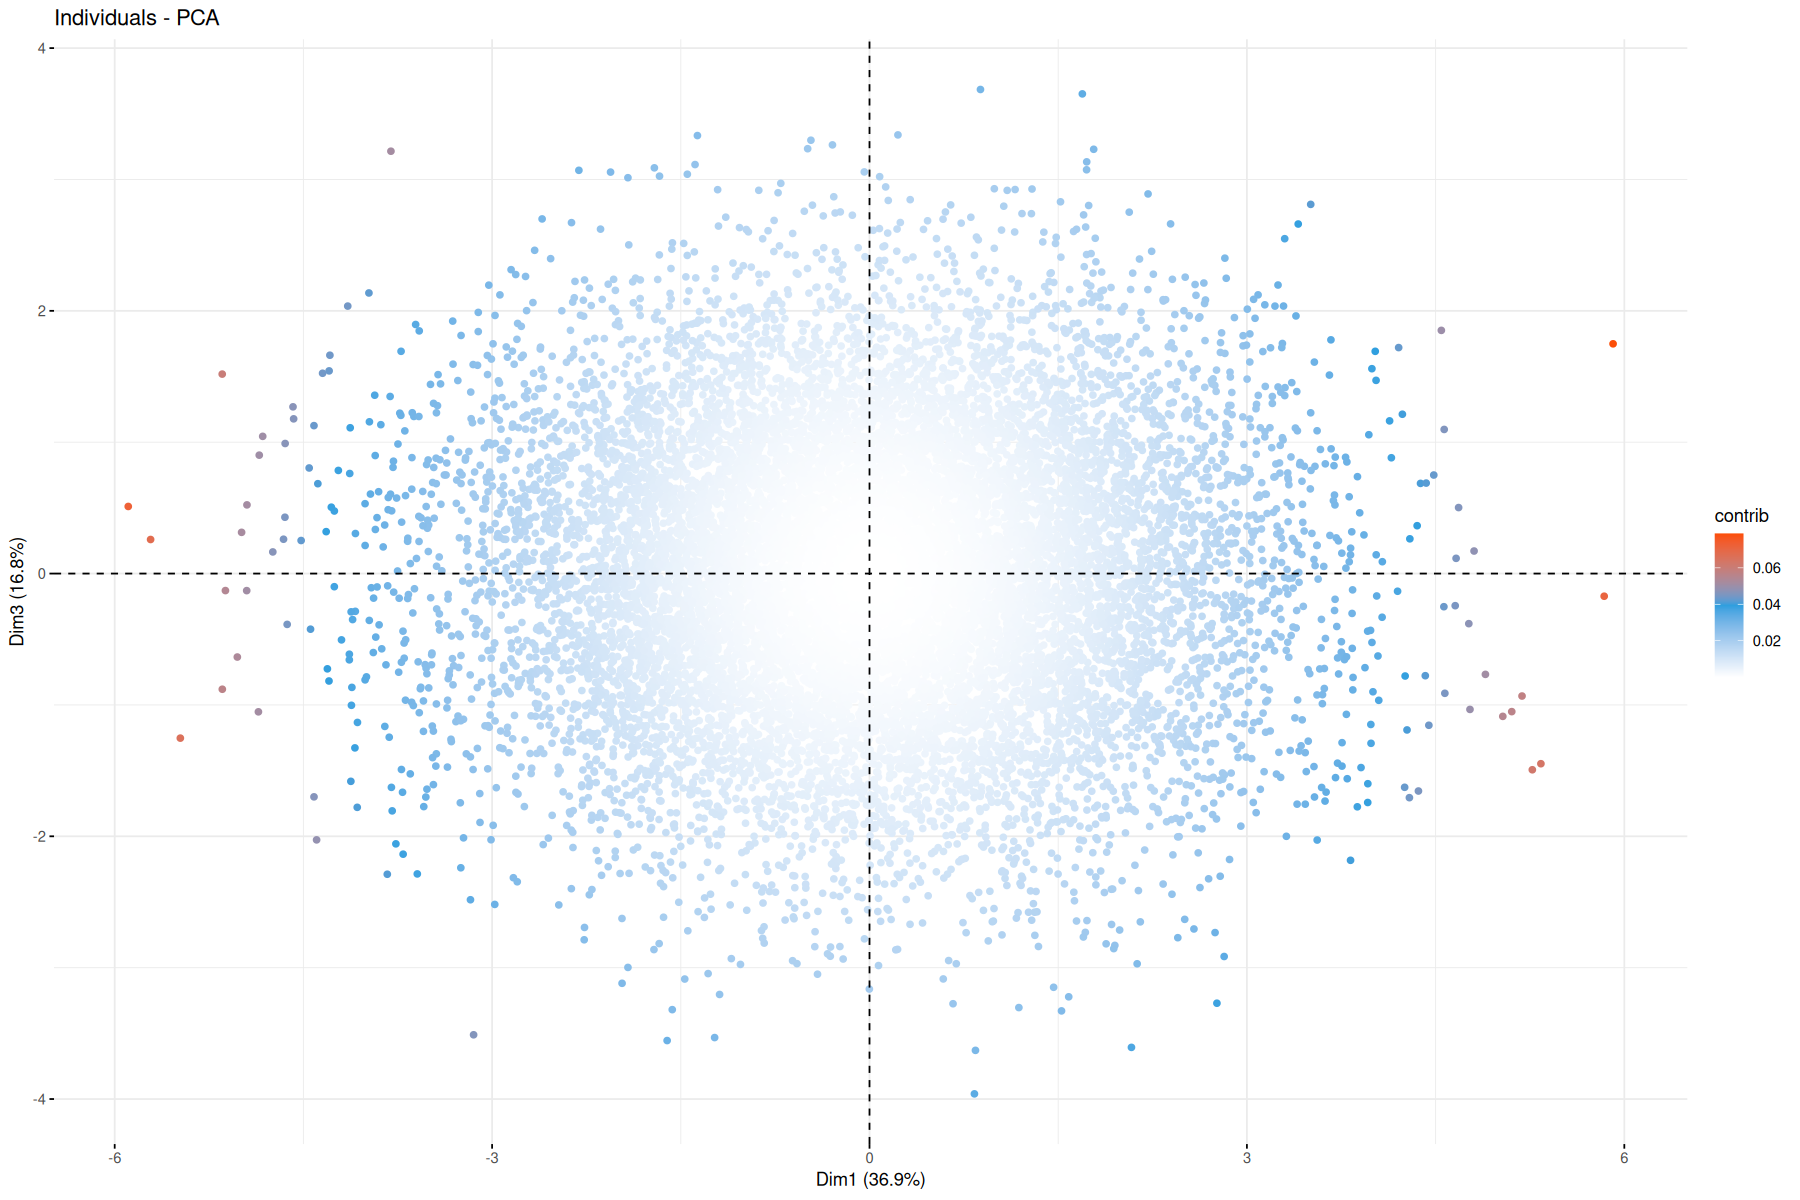

In [89]:
fviz_pca_var(acp)
fviz_pca_ind(acp,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ))
fviz_pca_var(acp,axes=c(1,3))
fviz_pca_ind(acp,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(1,3))

<div style="border-left:5px solid orange; padding:15px; background-color:#fff8e1; border-radius:5px; font-family:Arial, sans-serif; line-height:1.6;">
  <strong>Interprétation :</strong><br><br>

  <em>Premier graphe (dim 1 et dim 2) :</em><br>
  - <strong>Systolic_BP</strong> et <strong>Diastolic_BP</strong> sont fortement corrélées.<br>
  - <strong>Cholesterol_Total</strong> et <strong>Cholesterol_LDL</strong> sont corrélés positivement.<br>
  - <strong>Cholesterol_HDL</strong> et <strong>BMI</strong> sont corrélés négativement.<br>
  - <strong>Fasting_Blood_Sugar</strong> et <strong>BMI</strong> présentent une légère corrélation positive.<br><br>

  <em>Deuxième graphe (dim 2 et dim 3) :</em><br>
  - À part <strong>BMI</strong>, <strong>Fasting_Blood_Sugar</strong> et <strong>Cholesterol_HDL</strong>, les variables sont fortement corrélées entre elles.
</div>

### Clustering

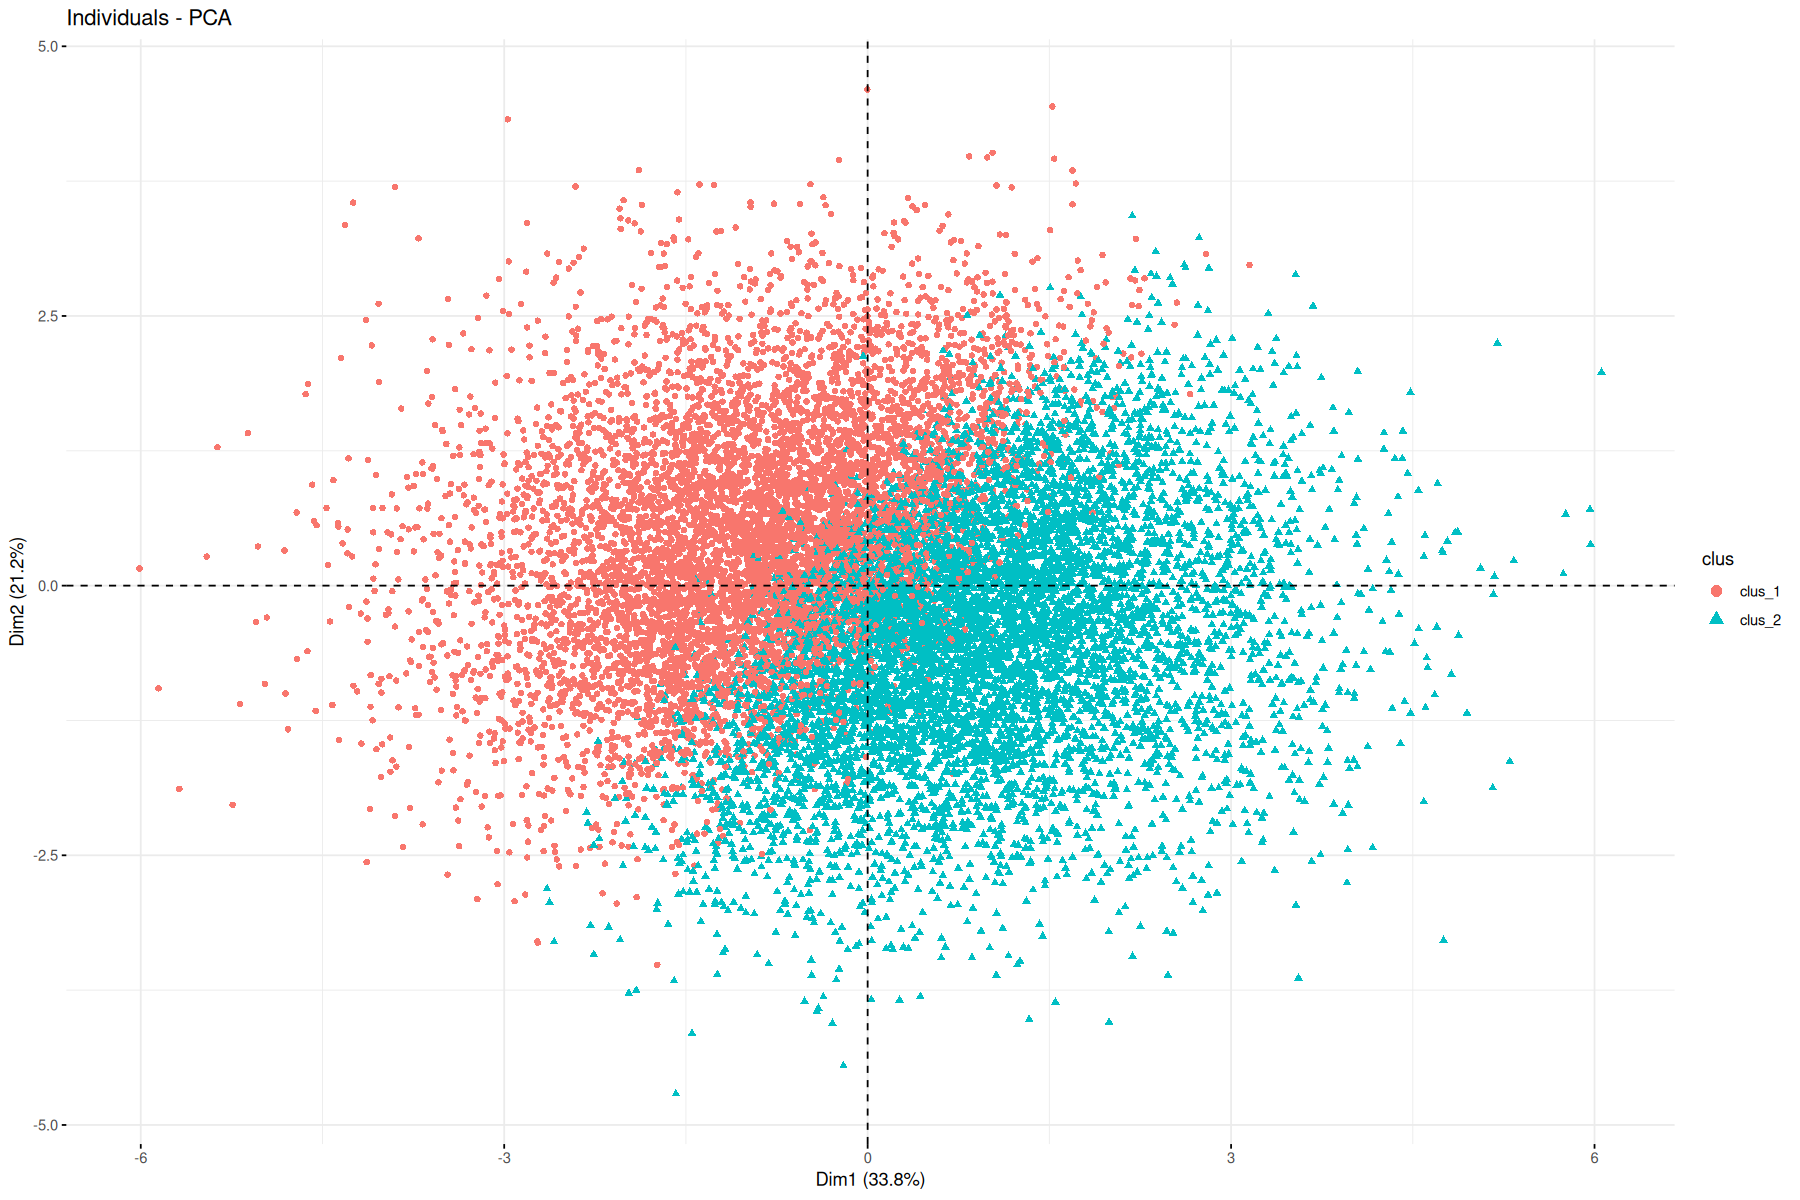

In [90]:
km.data <- kmeans(data[, c("Age", "BMI", "Systolic_BP", "Diastolic_BP","Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL", "Fasting_Blood_Sugar")],
  centers = 2)
# Représentation dans les coordonnées de l'acp
acp2 <- PCA(cbind(clus = as.factor(km.data$cluster),
          data[, c("Age", "BMI", "Systolic_BP", "Diastolic_BP",
                 "Cholesterol_Total", "Cholesterol_LDL",
                 "Cholesterol_HDL", "Fasting_Blood_Sugar")]), scale.unit = TRUE,
          graph = FALSE, quali.sup = 1:2, ncp = 7)
fviz_pca_ind(acp2, label="none", habillage="clus")

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b>  
</div>

# 3. Modélisation

###  Division du jeu de données en un échantillon d’apprentissage et un échantillon test

Pour évaluer correctement un modèle, on divise le jeu de données en échantillon d’apprentissage (80%) et échantillon test (20%). L’échantillon d’apprentissage sert à entraîner le modèle, tandis que l’échantillon test permet de mesurer ses performances sur des données jamais vues. Cette étape est nécessaire pour éviter le surapprentissage et obtenir une estimation réaliste de la capacité du modèle à généraliser à de nouvelles données.

In [91]:
set.seed(111) # initialisation du générateur
# Extraction des échantillons
test.ratio <- .2   # part de l'échantillon test
npop <- nrow(data) # nombre de lignes dans les données
nvar <- ncol(data) # nombre de colonnes
# taille de l'échantillon test
ntest <- ceiling(npop * test.ratio) 
# indices de l'échantillon test
testi <- sample(1:npop, ntest)
# indices de l'échantillon d'apprentissage
appri <- setdiff(1:npop, testi) 

Construction des échantillons pour la régression: prévision du risque d’accident cardiaque "Heart_Disease_Risk".

ENLEVER LE HEART_DISEASE_RISK POUR ETUDE DU CHOLESTEROL

In [92]:
# construction de l'échantillon d'apprentissage
datappr0 <- data[appri, -c(1, 19)]

# construction de l'échantillon test
datestr0 <- data[testi, -c(1, 19)] 

# vérification
str(datappr0)
str(datestr0)

# on identifie les colonnes numériques
num_cols <- sapply(datappr0, is.numeric)

# on normalise l'échantillon d'apprentissage (seulement les variables numeric et integer)
datappr <- datappr0
datappr[, num_cols] <- scale(datappr0[, num_cols])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestr <- datestr0
datestr[, num_cols] <- scale(
  datestr0[, num_cols],
  center = sapply(datappr0[, num_cols], mean), # on centre avec les moyennes de l'échantillon d'apprentissage
  scale  = sapply(datappr0[, num_cols], sd)    # on réduit avec les écart-types de l'échantillon d'apprentissage
)

# vérification
summary(datappr)
summary(datestr)

'data.frame':	12000 obs. of  17 variables:
 $ Age                    : int  60 53 62 73 52 73 64 49 61 49 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  147 162 175 173 160 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 60.3 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 23.7 25 34.5 28.2 36.3 33.9 ...
 $ Systolic_BP            : int  140 128 141 136 134 149 129 139 131 150 ...
 $ Diastolic_BP           : int  89 81 100 96 92 98 90 91 91 100 ...
 $ Cholesterol_Total      : int  217 203 173 193 225 260 237 227 206 188 ...
 $ Cholesterol_LDL        : int  151 119 124 117 155 166 160 138 139 129 ...
 $ Cholesterol_HDL        : int  52 38 45 45 48 46 44 37 38 43 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 103 103 108 90 103 106 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 2 1 1 1 1 1 2 1 1 1 ...
 $

      Age           Gender     Height_cm          Weight_kg       
 Min.   :-2.46911   0:6083   Min.   :-2.91995   Min.   :-2.95670  
 1st Qu.:-0.71488   1:5917   1st Qu.:-0.74279   1st Qu.:-0.71629  
 Median : 0.03694            Median :-0.06788   Median :-0.09554  
 Mean   : 0.00000            Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.70522            3rd Qu.: 0.73767   3rd Qu.: 0.61796  
 Max.   : 2.54298            Max.   : 3.53532   Max.   : 5.34851  
      BMI           Systolic_BP        Diastolic_BP      Cholesterol_Total 
 Min.   :-3.1570   Min.   :-3.98919   Min.   :-3.60504   Min.   :-3.70977  
 1st Qu.:-0.7112   1st Qu.:-0.71768   1st Qu.:-0.65311   1st Qu.:-0.67073  
 Median :-0.0753   Median :-0.01033   Median : 0.05535   Median : 0.03397  
 Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.6340   3rd Qu.: 0.69702   3rd Qu.: 0.64573   3rd Qu.: 0.69463  
 Max.   : 4.4984   Max.   : 4.14536   Max.   : 3.47959   Max.   : 3.73367  

      Age            Gender     Height_cm           Weight_kg       
 Min.   :-2.469112   0:1539   Min.   :-2.919954   Min.   :-2.52147  
 1st Qu.:-0.631343   1:1461   1st Qu.:-0.742795   1st Qu.:-0.70202  
 Median :-0.046599            Median :-0.067876   Median :-0.05987  
 Mean   :-0.008228            Mean   : 0.007207   Mean   : 0.04050  
 3rd Qu.: 0.621681            3rd Qu.: 0.715902   3rd Qu.: 0.66791  
 Max.   : 2.542985            Max.   : 3.567980   Max.   : 4.54939  
      BMI            Systolic_BP         Diastolic_BP       Cholesterol_Total  
 Min.   :-2.59448   Min.   :-3.547092   Min.   :-3.132733   Min.   :-3.929990  
 1st Qu.:-0.71121   1st Qu.:-0.629264   1st Qu.:-0.653114   1st Qu.:-0.670732  
 Median :-0.05084   Median :-0.010330   Median :-0.003690   Median :-0.010071  
 Mean   : 0.04674   Mean   : 0.000368   Mean   : 0.005914   Mean   : 0.004258  
 3rd Qu.: 0.65845   3rd Qu.: 0.697022   3rd Qu.: 0.645734   3rd Qu.: 0.650589  
 Max.   : 4.57174   Max.   : 2.995917

Construction des échantillons pour la discrimination: prévision du risque d’accident cardiaque "Heart_Disease_Risk".

In [93]:
# construction de l'échantillon d'apprentissage
datappq0 <- data[appri, -1]

# construction de l'échantillon test
datestq0 <- data[testi, -1] 

# vérification
str(datappq0)
str(datestq0)

# on identifie les colonnes numériques
num_cols <- sapply(datappq0, is.numeric)

# on normalise l'échantillon d'apprentissage (seulement les variables numeric et integer)
datappq <- datappq0
datappq[, num_cols] <- scale(datappq0[, num_cols])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestq <- datestq0
datestq[, num_cols] <- scale(
  datestq0[, num_cols],
  center = sapply(datappq0[, num_cols], mean), # on centre avec les moyennes de l'échantillon d'apprentissage
  scale  = sapply(datappq0[, num_cols], sd)    # on réduit avec les écart-types de l'échantillon d'apprentissage
)

# vérification
summary(datappq)
summary(datestq)

'data.frame':	12000 obs. of  18 variables:
 $ Age                    : int  60 53 62 73 52 73 64 49 61 49 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  147 162 175 173 160 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 60.3 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 23.7 25 34.5 28.2 36.3 33.9 ...
 $ Systolic_BP            : int  140 128 141 136 134 149 129 139 131 150 ...
 $ Diastolic_BP           : int  89 81 100 96 92 98 90 91 91 100 ...
 $ Cholesterol_Total      : int  217 203 173 193 225 260 237 227 206 188 ...
 $ Cholesterol_LDL        : int  151 119 124 117 155 166 160 138 139 129 ...
 $ Cholesterol_HDL        : int  52 38 45 45 48 46 44 37 38 43 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 103 103 108 90 103 106 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 2 1 1 1 1 1 2 1 1 1 ...
 $

      Age           Gender     Height_cm          Weight_kg       
 Min.   :-2.46911   0:6083   Min.   :-2.91995   Min.   :-2.95670  
 1st Qu.:-0.71488   1:5917   1st Qu.:-0.74279   1st Qu.:-0.71629  
 Median : 0.03694            Median :-0.06788   Median :-0.09554  
 Mean   : 0.00000            Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.70522            3rd Qu.: 0.73767   3rd Qu.: 0.61796  
 Max.   : 2.54298            Max.   : 3.53532   Max.   : 5.34851  
      BMI           Systolic_BP        Diastolic_BP      Cholesterol_Total 
 Min.   :-3.1570   Min.   :-3.98919   Min.   :-3.60504   Min.   :-3.70977  
 1st Qu.:-0.7112   1st Qu.:-0.71768   1st Qu.:-0.65311   1st Qu.:-0.67073  
 Median :-0.0753   Median :-0.01033   Median : 0.05535   Median : 0.03397  
 Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.6340   3rd Qu.: 0.69702   3rd Qu.: 0.64573   3rd Qu.: 0.69463  
 Max.   : 4.4984   Max.   : 4.14536   Max.   : 3.47959   Max.   : 3.73367  

      Age            Gender     Height_cm           Weight_kg       
 Min.   :-2.469112   0:1539   Min.   :-2.919954   Min.   :-2.52147  
 1st Qu.:-0.631343   1:1461   1st Qu.:-0.742795   1st Qu.:-0.70202  
 Median :-0.046599            Median :-0.067876   Median :-0.05987  
 Mean   :-0.008228            Mean   : 0.007207   Mean   : 0.04050  
 3rd Qu.: 0.621681            3rd Qu.: 0.715902   3rd Qu.: 0.66791  
 Max.   : 2.542985            Max.   : 3.567980   Max.   : 4.54939  
      BMI            Systolic_BP         Diastolic_BP       Cholesterol_Total  
 Min.   :-2.59448   Min.   :-3.547092   Min.   :-3.132733   Min.   :-3.929990  
 1st Qu.:-0.71121   1st Qu.:-0.629264   1st Qu.:-0.653114   1st Qu.:-0.670732  
 Median :-0.05084   Median :-0.010330   Median :-0.003690   Median :-0.010071  
 Mean   : 0.04674   Mean   : 0.000368   Mean   : 0.005914   Mean   : 0.004258  
 3rd Qu.: 0.65845   3rd Qu.: 0.697022   3rd Qu.: 0.645734   3rd Qu.: 0.650589  
 Max.   : 4.57174   Max.   : 2.995917

In [94]:
# code pour trouver les variables numeric mais inutile 
# str(datappr0)  # regarde le type de chaque colonne
# sapply(datappr0, class)  # renvoie le type

In [95]:
#Enfin, avant de passer aux différents algorithmes, définissons une fonction traçant le graphe des résidus avec des couleurs et des échelles fixes sur les axes.
#c'était dans le TP à voir si c'est utile

gplot.res <- function(x, y, titre = "titre"){
    ggplot(data.frame(x=x, y=y),aes(x,y))+
    geom_point(col = "blue")+xlim(0, 250)+ylim(-155, 155)+
    ylab("Résidus")+ xlab("Valeurs prédites")+
    ggtitle(titre)+
    geom_hline(yintercept = 0,col="green")
}

consigne : Comparez les performances d’un modèle linéaire (éventuellement généralisé) avec/sans sélection de vari
ables, avec/sans pénalisation, d’un SVR/SVM, d’un arbre optimal, d’une forêt aléatoire, du boosting,
et de réseaux de neurones. Justifiez vos choix (par exemple le noyau pour le SVR/SVM), identifiez les
hyperparamètres de chaque modèle et ajustez-les soigneusement (par validation croisée). Interprétez les
résultats et quantifiez l’amélioration éventuelle apportée par les modèles non linéaires.

## 3.1 Prévision par modèle linéaire Gaussien 

modèle linéaire (éventuellement généralisé) avec/sans sélection de vari
ables, avec/sans pénalisatio. 

### 3.1.1 Sans sélection de variables

### 3.1.2. Sélection de variable par régularisation L1 (LASSO)

### 3.1.3 Modèle linéaire généralisé (quadratique)

### 3.1.4 Sélection de variables par critère AIC

### 3.1.5 Sélection de variable par régularisation L1 (LASSO)

### 3.1.6 Prévision de l'échantillon test

## Prévision par SVR/SVM (séparation à vaste marge)

## 3.3 Prévision par arbre binaire de discrimination

Nous allons maintenant réaliser une prévision par arbre de décision binaire (CART). Puisque nous souhaitons prédire la variable **Heart_Disease_Risk** qui est une variable qualitative, nous allons estimer un arbre binaire de discrimination (ou de décision).

### 3.3.1 Estimation et élagage de l'arbre de discrimination

##### 3.3.1.1 Critère : indice de concentration de Gini

Nous allons commencer notre estimation en utilisant la concentration de Gini comme critère discriminant.

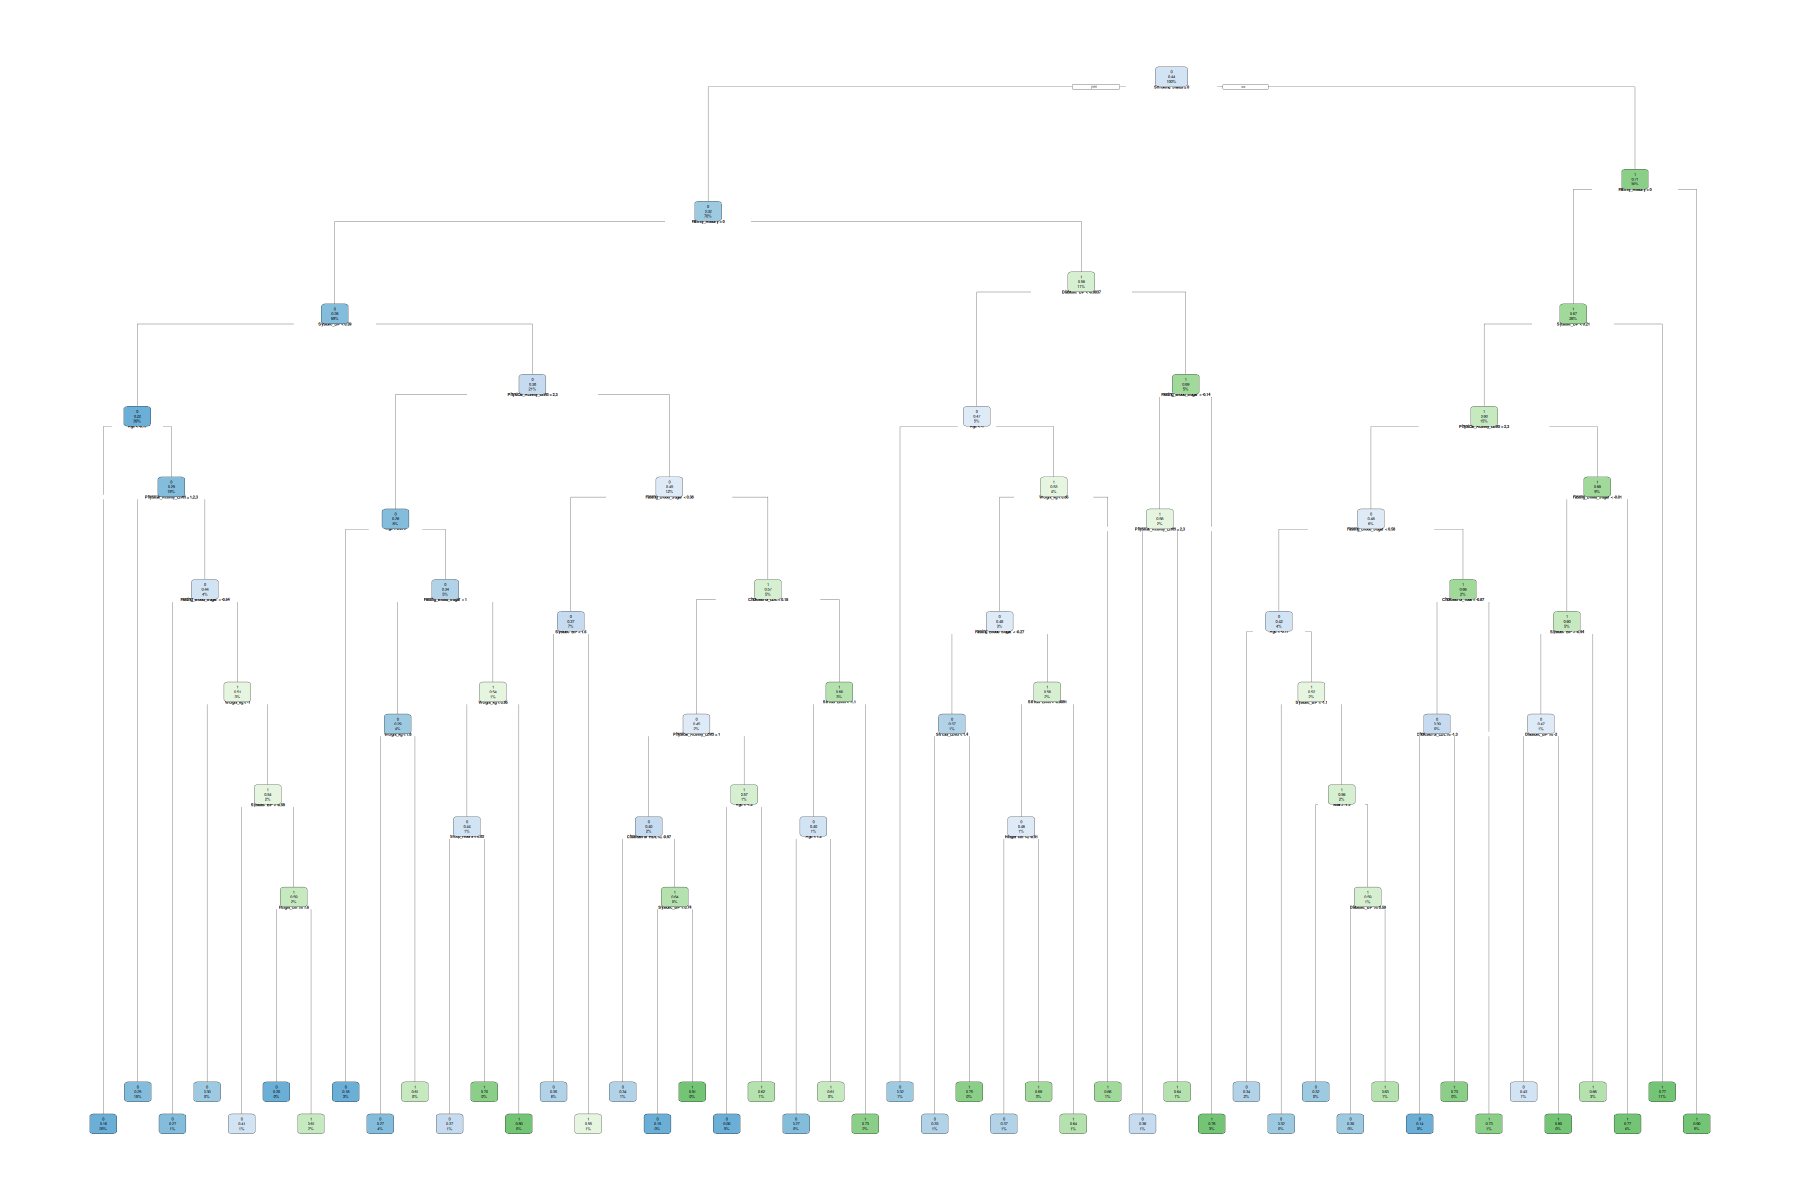

In [96]:
tree.dis=rpart(Heart_Disease_Risk~.,data=datappq,parms=list(split="gini"),cp=0.001)
options(repr.plot.width = 15, repr.plot.height = 10)
rpart.plot(tree.dis) 

In [106]:
xmat = xpred.rpart(tree.dis)
# Comparaison des valeurs prédite et observée
xerr=datappq$Heart_Disease_Risk!= (xmat>0.5) 
# Calcul  des estimations des taux d'erreur
CVerr=apply(xerr, 2, sum)/nrow(xerr)
CVerr

0.640779468 0.102689230 0.015786338 0.005771666 0.004877948 0.004656825 
          1           1           1           1           1           1 
0.004242569 0.003774854 0.003209495 0.002654798 0.002273434 0.001993933 
          1           1           1           1           1           1 
0.001853003 0.001757913 0.001613171 0.001422683 0.001232080 0.001092122 
          1           1           1           1           1           1 
0.001022559 
          1

[1] 0.6407795

Call:
rpart(formula = Heart_Disease_Risk ~ ., data = datappq, parms = list(split = "information"), 
    cp = as.numeric(attributes(which.min(CVerr))$names))
  n= 12000 

         CP nsplit rel error xerror xstd
1 0.2815589      0         1      0    0

Node number 1: 12000 observations
  predicted class=0  expected loss=0.4383333  P(node) =1
    class counts:  6740  5260
   probabilities: 0.562 0.438 



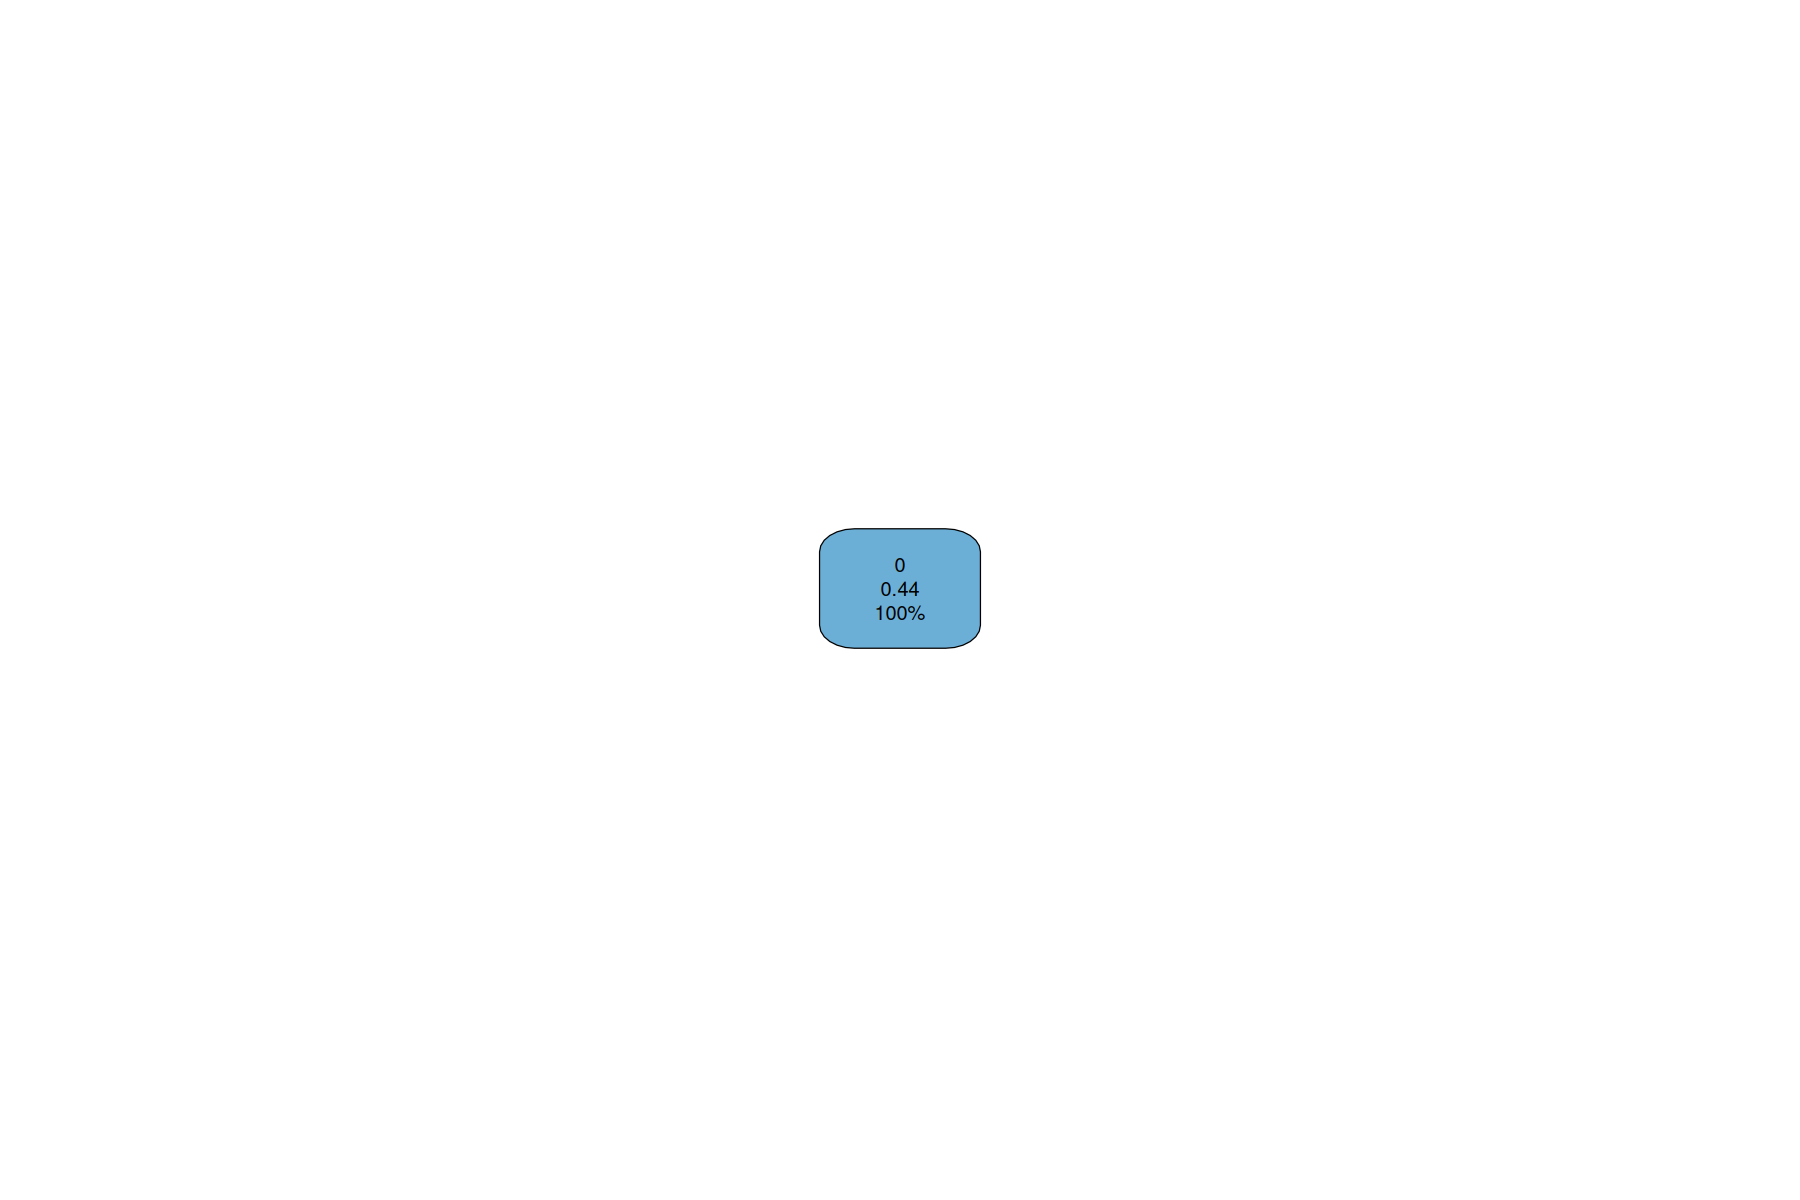

In [109]:
as.numeric(attributes(which.min(CVerr))$names)
tree.dis.prun=rpart(Heart_Disease_Risk~.,data=datappq,parms=list(split="information"),cp=as.numeric(attributes(which.min(CVerr))$names))
rpart.plot(tree.dis.prun,type=4)
summary(tree.dis.prun)

In [110]:
printcp(tree.dis.prun)


Classification tree:
rpart(formula = Heart_Disease_Risk ~ ., data = datappq, parms = list(split = "information"), 
    cp = as.numeric(attributes(which.min(CVerr))$names))

Variables actually used in tree construction:
character(0)

Root node error: 5260/12000 = 0.43833

n= 12000 

       CP nsplit rel error xerror xstd
1 0.28156      0         1      0    0


[1] 0.6407795

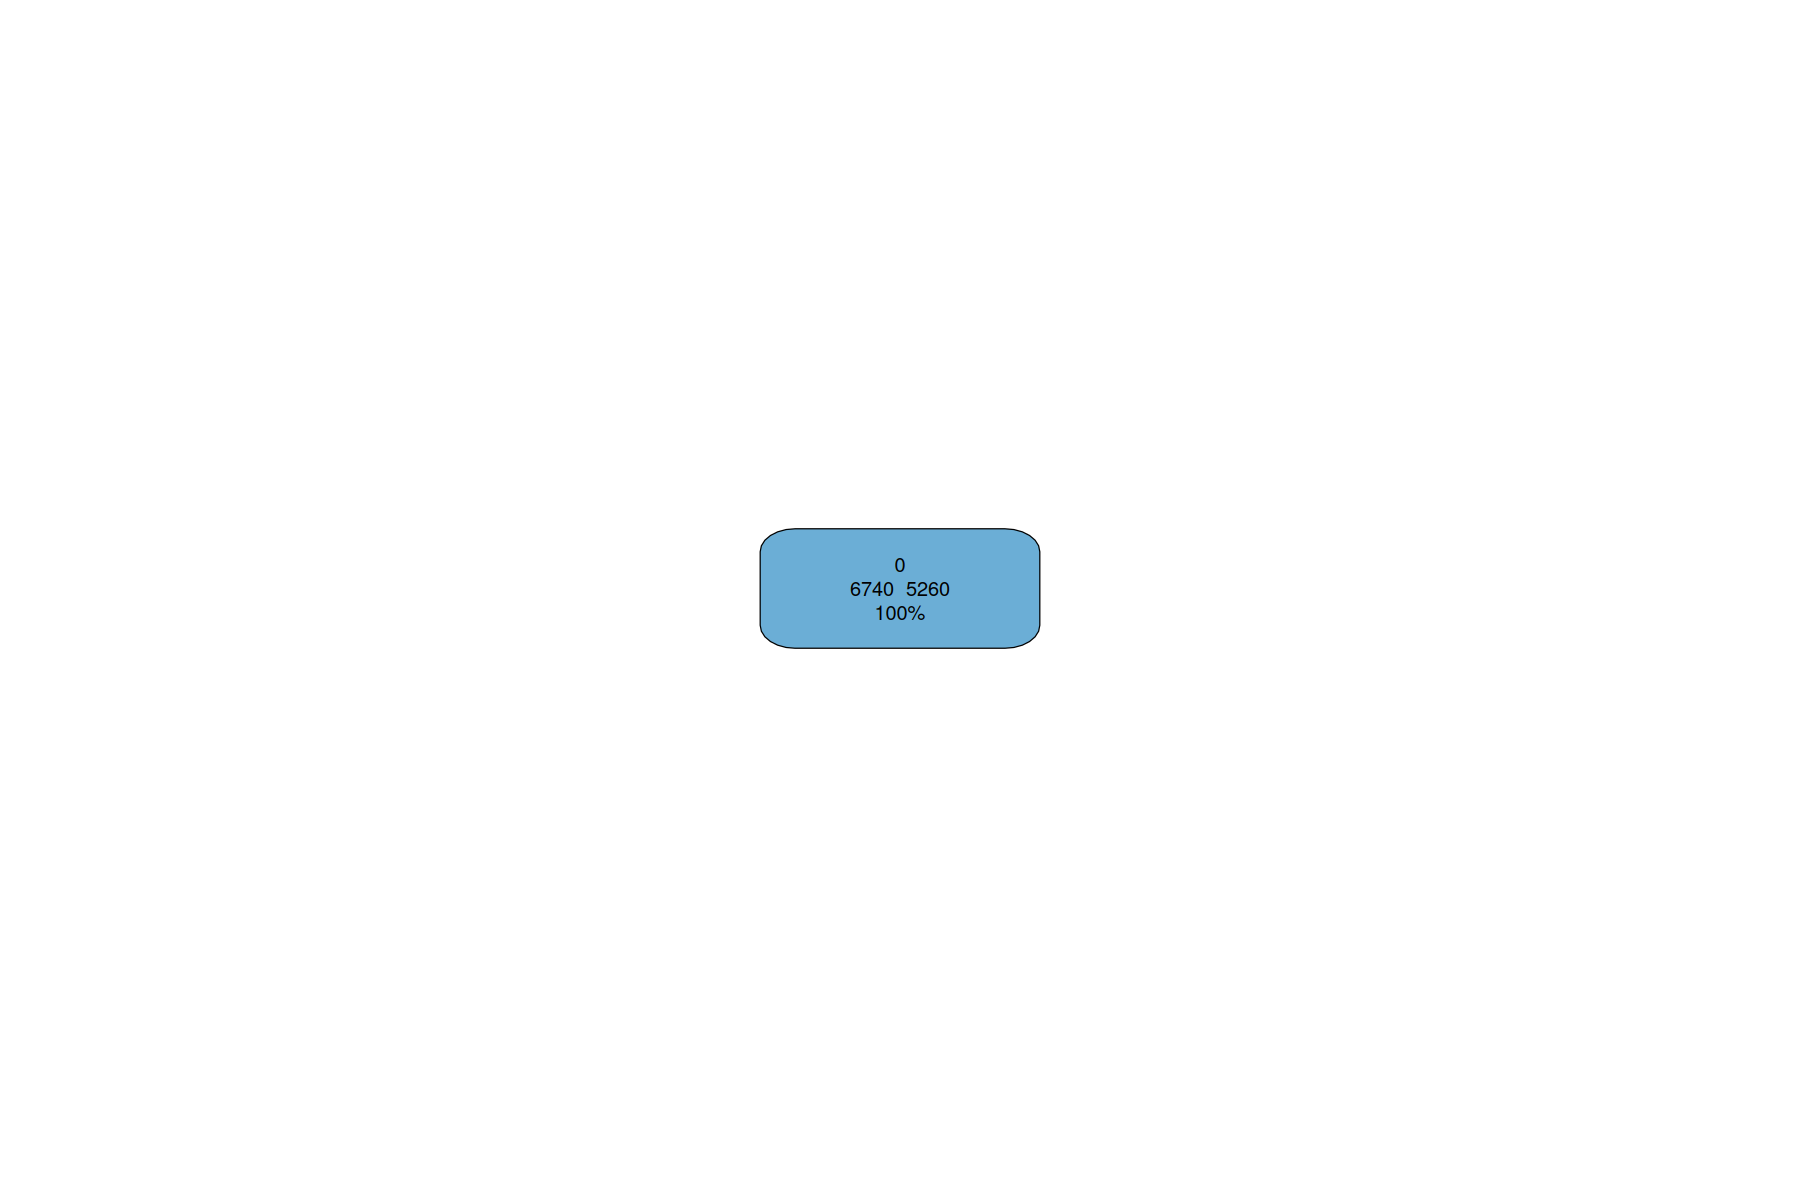

In [103]:
#bizarre l'ambiance, ça devrait pas être un seul truc sans 

# trouve la complexité avec la plus petite erreur relative
as.numeric(attributes(which.min(CVerr))$names)
# change l'arbre en choisissant la taille de l'arbre correspondant à cette complexité
tree.dis.prun=rpart(Heart_Disease_Risk~.,data=datappq,control=rpart.control(cp=as.numeric(attributes(which.min(CVerr))$names)))
# plot le nouvel arbre
rpart.plot(tree.dis.prun,type=5,extra=101)

In [104]:
printcp(tree.dis.prun)


Classification tree:
rpart(formula = Heart_Disease_Risk ~ ., data = datappq, control = rpart.control(cp = as.numeric(attributes(which.min(CVerr))$names)))

Variables actually used in tree construction:
character(0)

Root node error: 5260/12000 = 0.43833

n= 12000 

       CP nsplit rel error xerror xstd
1 0.28156      0         1      0    0


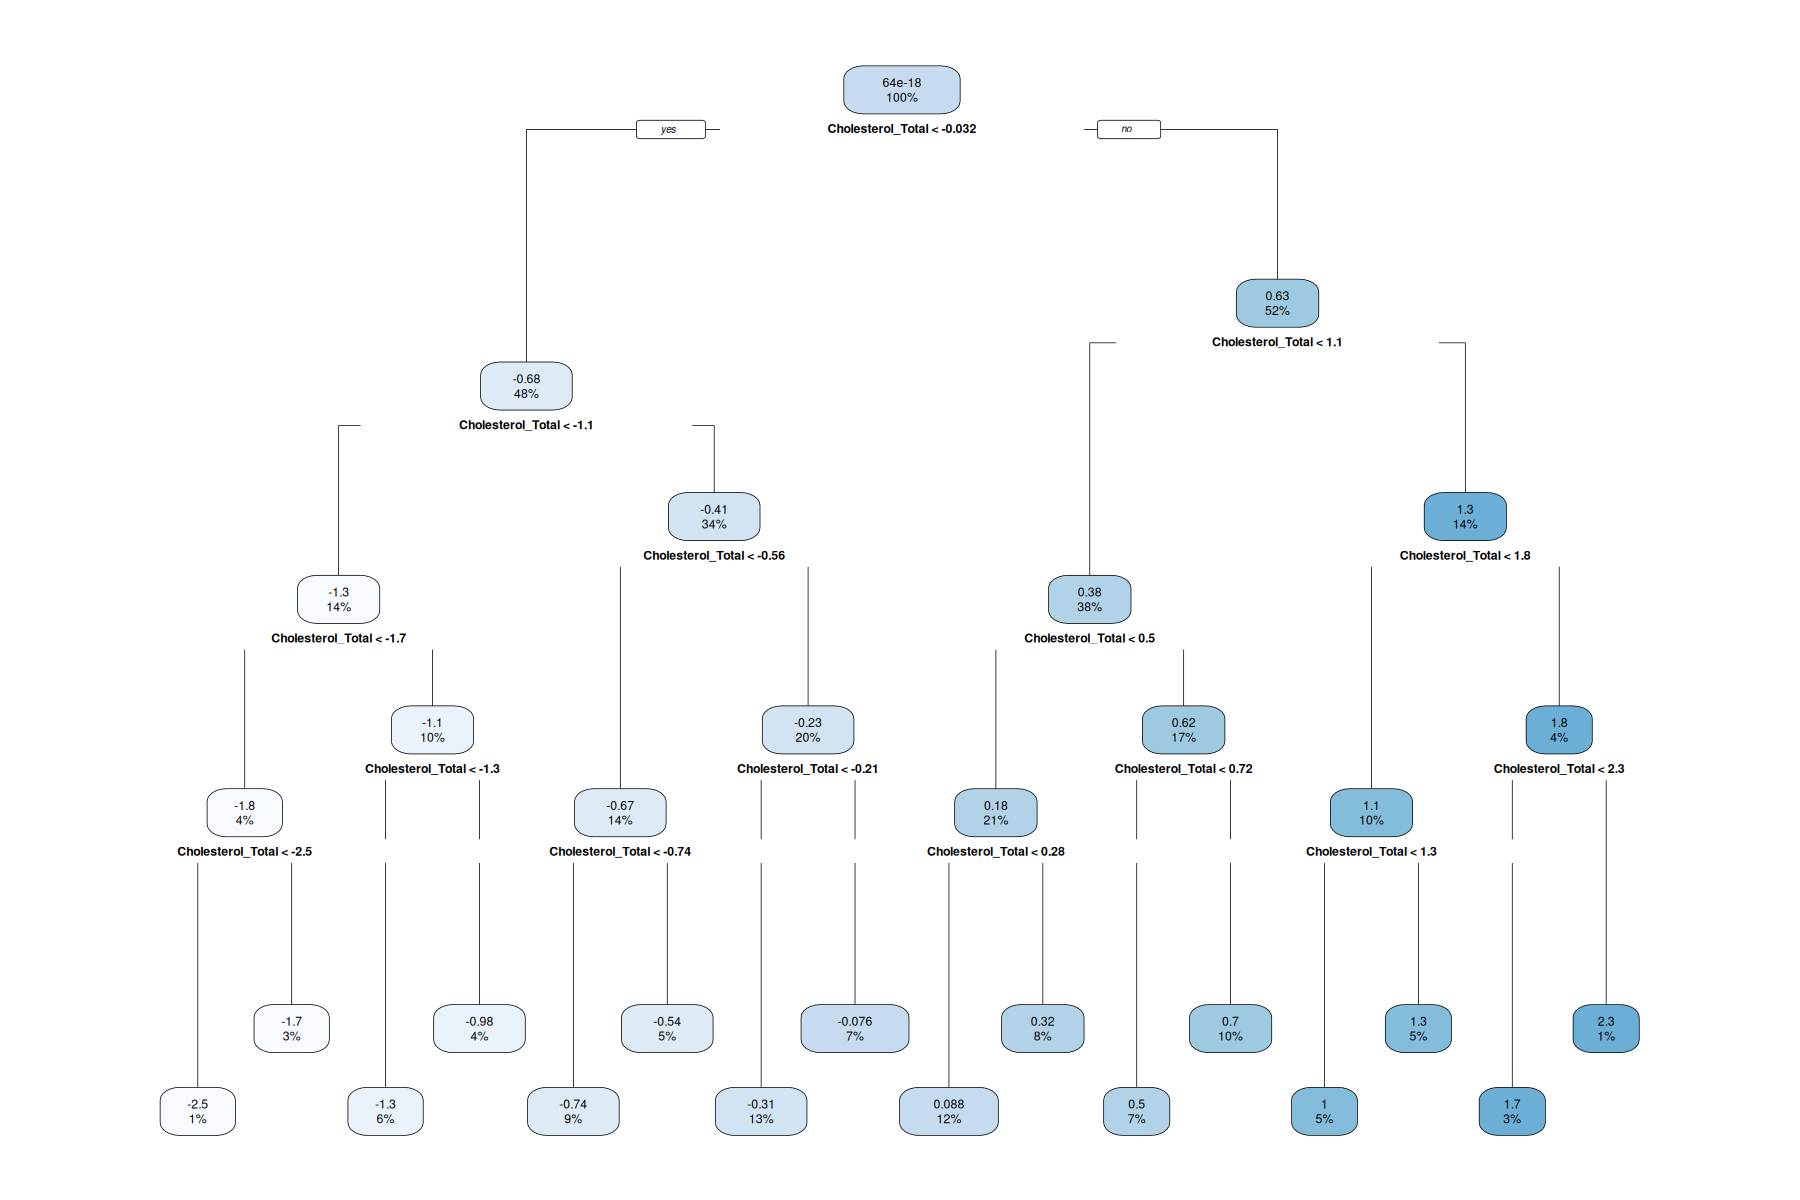

In [99]:
# test sur arbre de régression mais ça marche pas non plus ==> update : en fait ça marche
tree.reg=rpart(Cholesterol_LDL~.,data=datappr,control=rpart.control(cp=0.001))
options(repr.plot.width = 15, repr.plot.height = 10)
rpart.plot(tree.reg)

In [100]:
help(rpart)
# datappq
# datappq$Heart_Disease_Risk

rpart {rpart},R Documentation
formula,"a formula, with a response but no interaction terms. If this is a data frame, it is taken as the model frame (see model.frame)."
data,an optional data frame in which to interpret the variables named in the formula.
weights,optional case weights.
subset,optional expression saying that only a subset of the rows of the data should be used in the fit.
na.action,"the default action deletes all observations for which y is missing, but keeps those in which one or more predictors are missing."
method,"one of ""anova"", ""poisson"", ""class"" or ""exp"". If method is missing then the routine tries to make an intelligent guess. If y is a survival object, then method = ""exp"" is assumed, if y has 2 columns then method = ""poisson"" is assumed, if y is a factor then method = ""class"" is assumed, otherwise method = ""anova"" is assumed. It is wisest to specify the method directly, especially as more criteria may added to the function in future. Alternatively, method can be a list of functions named init, split and eval. Examples are given in the file ‘tests/usersplits.R’ in the sources, and in the vignettes ‘User Written Split Functions’."
model,"if logical: keep a copy of the model frame in the result? If the input value for model is a model frame (likely from an earlier call to the rpart function), then this frame is used rather than constructing new data."
x,keep a copy of the x matrix in the result.
y,keep a copy of the dependent variable in the result. If missing and model is supplied this defaults to FALSE.
parms,"optional parameters for the splitting function. Anova splitting has no parameters. Poisson splitting has a single parameter, the coefficient of variation of the prior distribution on the rates. The default value is 1. Exponential splitting has the same parameter as Poisson. For classification splitting, the list can contain any of: the vector of prior probabilities (component prior), the loss matrix (component loss) or the splitting index (component split). The priors must be positive and sum to 1. The loss matrix must have zeros on the diagonal and positive off-diagonal elements. The splitting index can be gini or information. The default priors are proportional to the data counts, the losses default to 1, and the split defaults to gini."


In [101]:
xmat = xpred.rpart(tree.dis)
# Comparaison des valeurs prédite et observée
xerr=datappr$Heart_Disease_Risk!= (xmat>1.5) 
# Calcul  des estimations des taux d'erreur
CVerr=apply(xerr, 2, sum)/nrow(xerr)
CVerr

ERROR: Error in apply(xerr, 2, sum): dim(X) doit avoir un longueur positive


In [ ]:
as.numeric(attributes(which.min(CVerr))$names)
tree.dis=rpart(Heart_Disease_Risk~.,data=datappr,parms=list(split="information"),cp=as.numeric(attributes(which.min(CVerr))$names))
rpart.plot(tree.dis,type=4)

##### 3.3.1.2 Critère : la cross-entropy

#### 3.3.2 Prévision de l'échantillon de test

##### 3.3.2.1 Erreur de classification (matrice de confusion)

##### 3.3.2.2 Courbes ROC

## Prévision par forêt aléatoire

## Prévision par boosting

## Prévision par réseaux de neurones